In [2]:
"""IMPORTAR"""

import pandas as pd
import os
from scipy.interpolate import PchipInterpolator
import numpy as np
import copy
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from tqdm import tqdm
import matplotlib.pyplot as plt

import importlib
import funciones
importlib.reload(funciones)
print()
from funciones import J_univariante, generar_uniforme_centrada, interpolador, remover_duplicados

from music21 import *
environment.set('musescoreDirectPNGPath', r"C:\Program Files\MuseScore 4\bin\MuseScore4.exe")


In [3]:
def process_notes(m21_data, start_measure=1):
    notes = []
    
    for part in m21_data.parts:
        for note in part.flatten().notes:
            try:
                measure = note.measureNumber + (start_measure - 1)
                start = float(note.offset)
                duration = float(note.quarterLength)
                
                if note.isChord:
                    for chord_note in note.pitches:
                        pitch = float(chord_note.ps)
                        notes.append([measure, start, start + duration, duration, pitch])
                else:
                    pitch = float(note.pitch.ps)
                    notes.append([measure, start, start + duration, duration, pitch])
            except:
                try:
                    start = float(note.offset)
                except:
                    try:
                        numer = note.offset.numerator
                        denom = note.offset.denominator
                        start = float(numer / denom)
                    except:
                        start = float(note.offset)
                
                try:
                    duration = float(note.quarterLength)
                except:
                    try:
                        numer = note.quarterLength.numerator
                        denom = note.quarterLength.denominator
                        duration = float(numer / denom)
                    except:
                        duration = float(note.quarterLength)
                
                for chord_note in note.pitches:
                    pitch = float(chord_note.ps)
                    notes.append([measure, start, start + duration, duration, pitch])
    
    all_notes = np.array(notes, dtype=object)
    n_measures = int(np.max(all_notes[:, 0]))
    
    timesig = []
    lquarters = []
    for i in range(n_measures + 1):
        try:
            ts = m21_data.parts[0].measure(i).timeSignature
            timesig.append([i, ts.ratioString])
            nquarters = ts.numerator / ts.denominator * 4
            lquarters.append([i, nquarters])
        except:
            pass
    
    measures_piece = []
    if len(timesig) > 1:
        for n_ts in range(1, len(timesig)):
            last_m = timesig[n_ts][0]
            first_m = timesig[n_ts - 1][0]
            ix = np.where((all_notes[:, 0] >= first_m) & (all_notes[:, 0] <= last_m))
            m_ts = [timesig[n_ts - 1][1]] * len(ix[0])
            measures_piece.append(np.column_stack((all_notes[ix], m_ts)))
        
        last_m = n_measures
        first_m = timesig[-1][0]
        ix = np.where((all_notes[:, 0] >= first_m) & (all_notes[:, 0] <= last_m))
        m_ts = [timesig[-1][1]] * len(ix[0])
        measures_piece.append(np.column_stack((all_notes[ix], m_ts)))
    else:
        m_ts = [timesig[0][1]] * len(all_notes)
        measures_piece.append(np.column_stack((all_notes, m_ts)))
    
    out_measures = np.vstack(measures_piece)
    return out_measures[np.lexsort((out_measures[:, 1].astype(float), out_measures[:, 0].astype(float)))]

def midi_to_note(midi_number):
    note_names = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
    octave = midi_number // 12 - 1
    note_index = midi_number % 12
    note = note_names[note_index]
    return f"{note}{octave}"

def midi_to_note_list(array):
    notas = []
    for x in array:
        # notas.append(columna[i])
        notas.append(midi_to_note(int(x)))
    return notas


def extract_midi_sequence(notes_matrix):
    unique_starts = np.unique(notes_matrix[:, 1].astype(float))
    midi_sequence = []
    
    for start in unique_starts:
        notes_at_start = notes_matrix[notes_matrix[:, 1].astype(float) == start]
        highest_pitch = np.max(notes_at_start[:, 4].astype(float))
        midi_sequence.append(highest_pitch)
    
    return midi_sequence

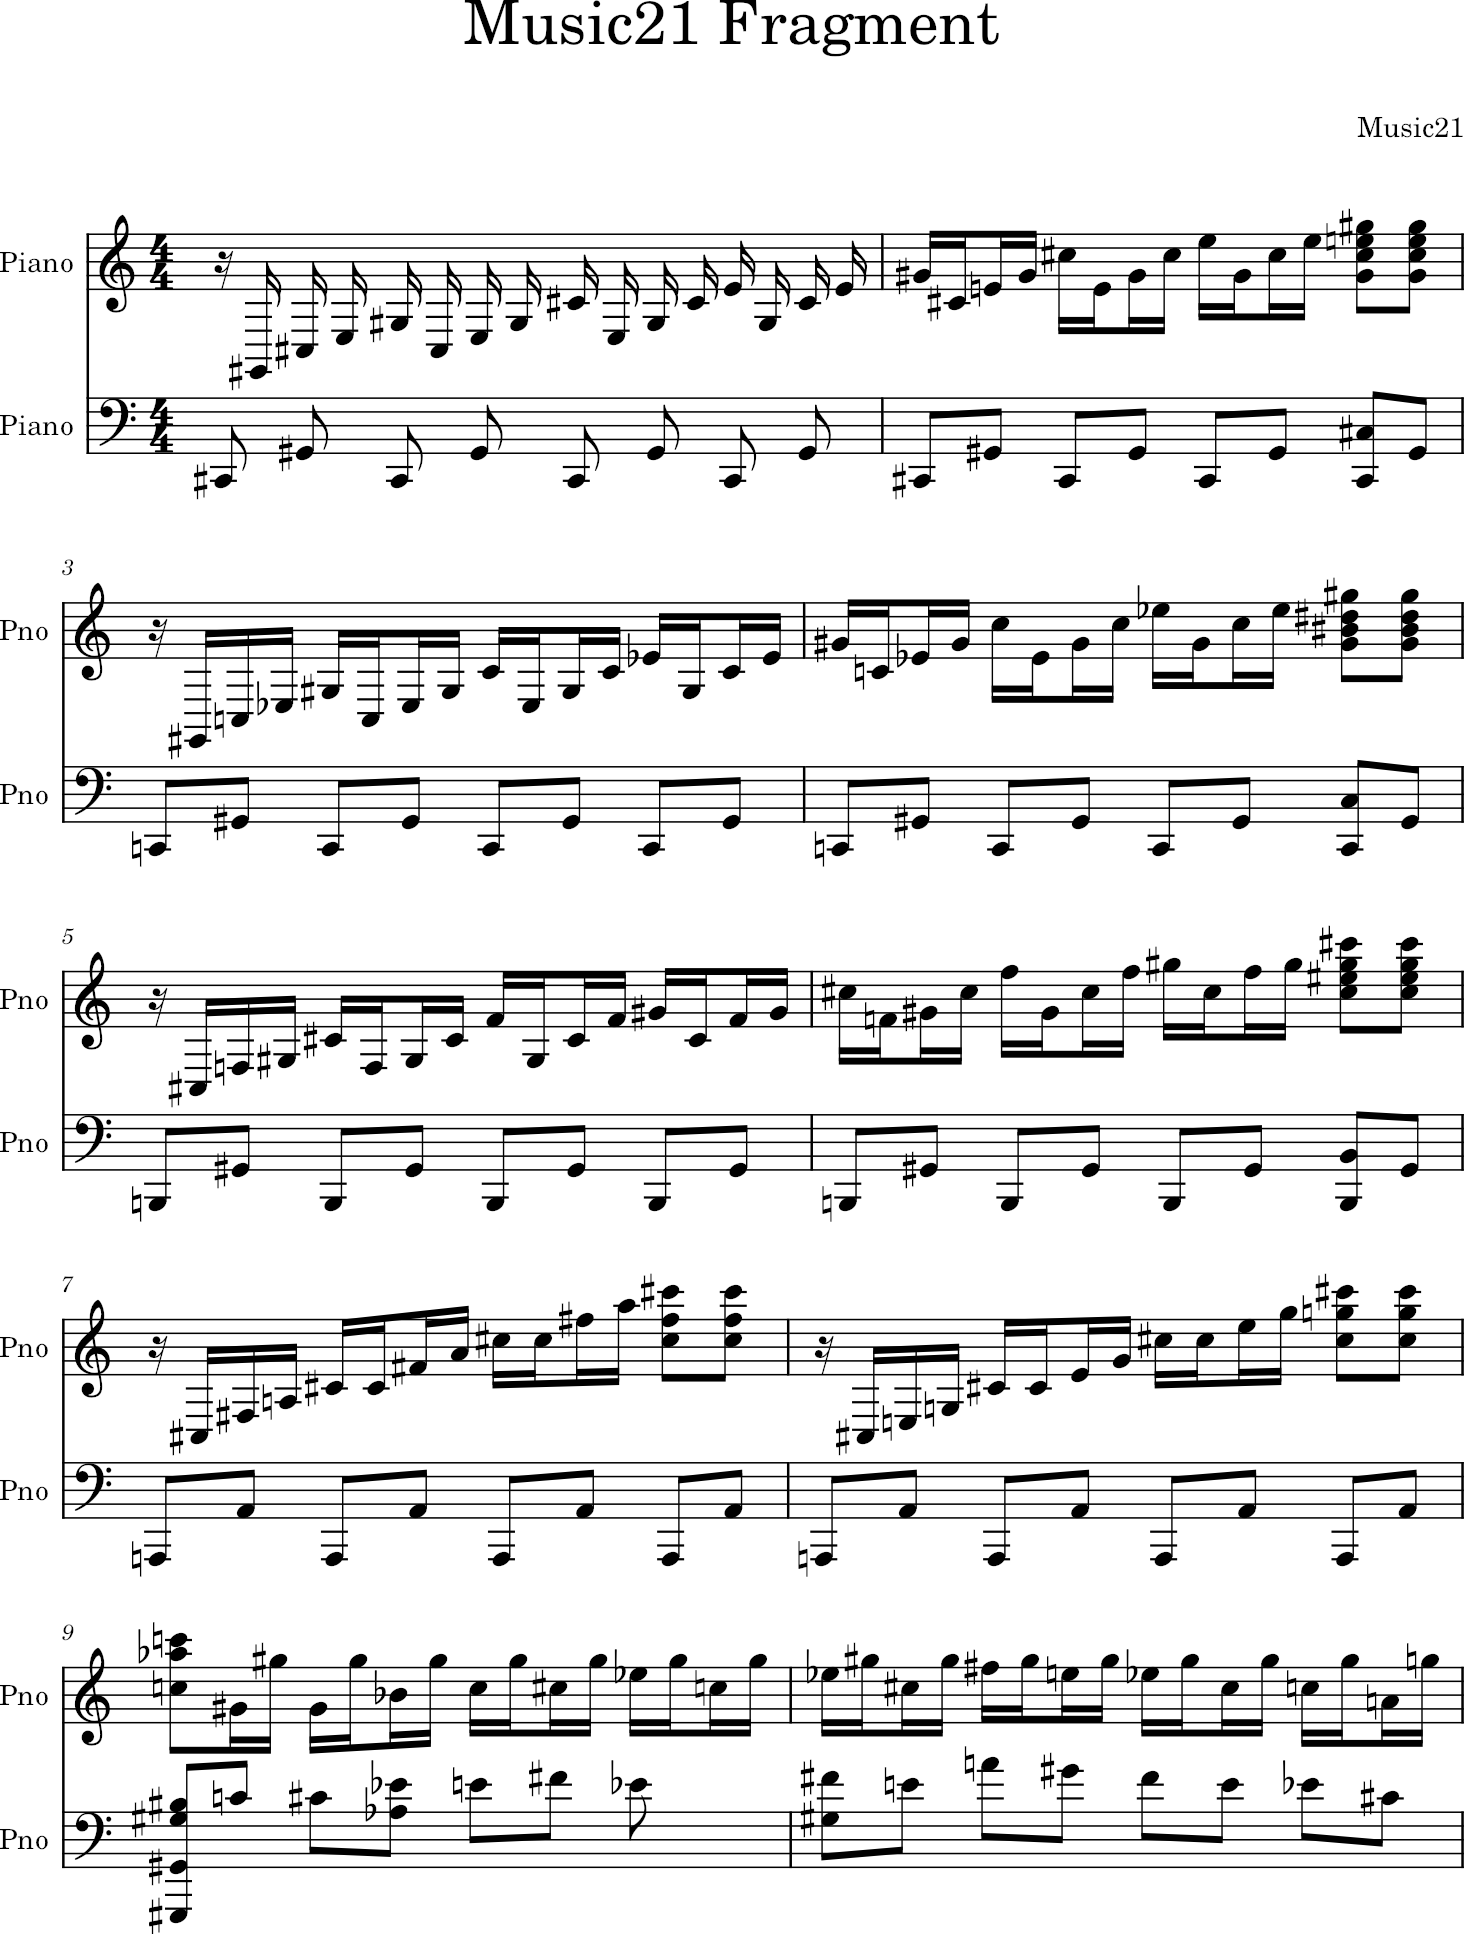

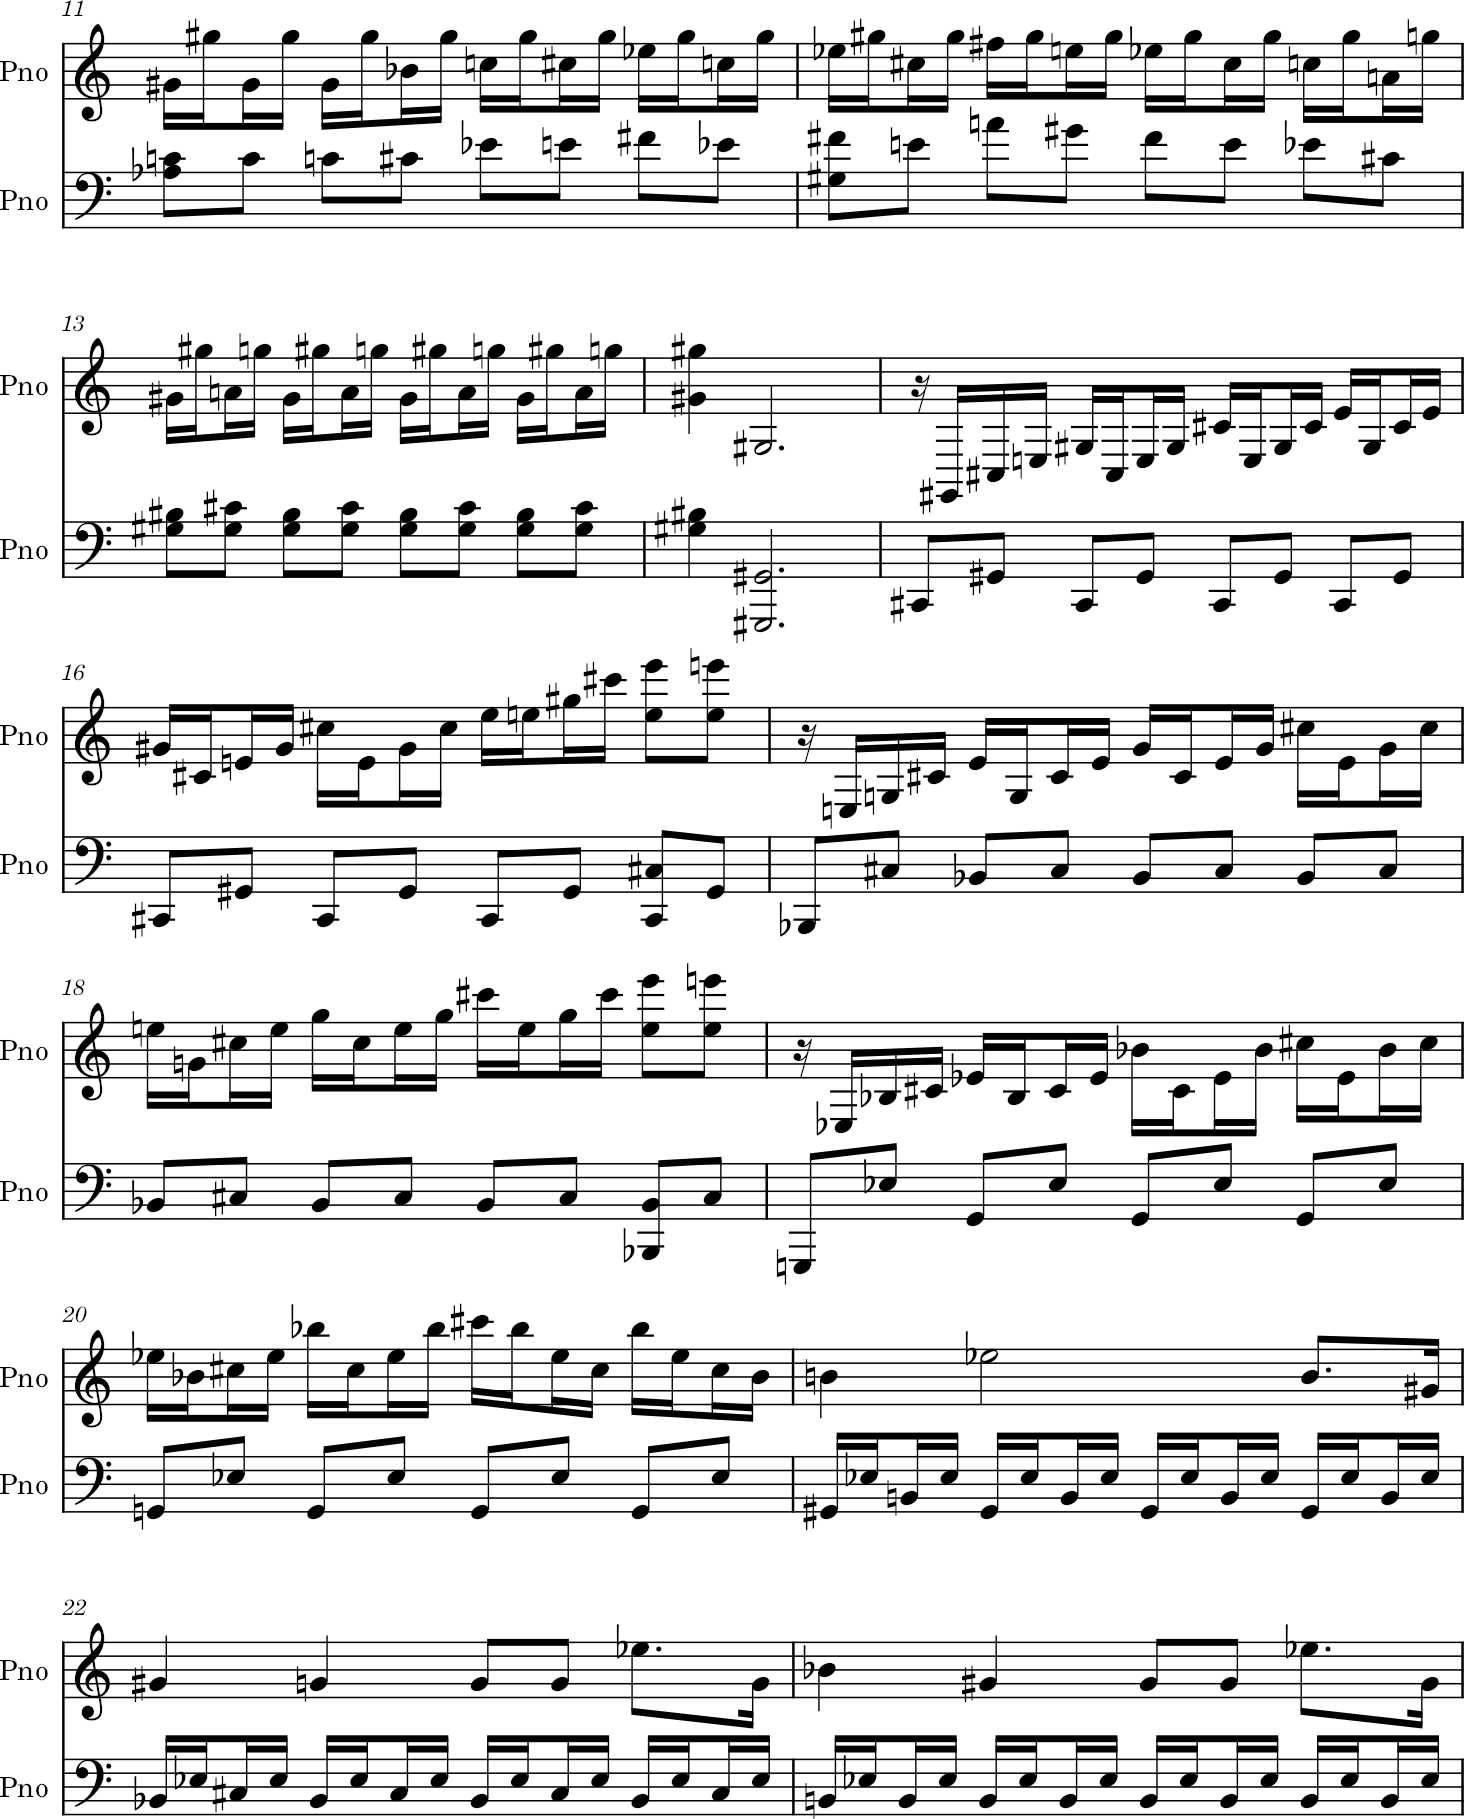

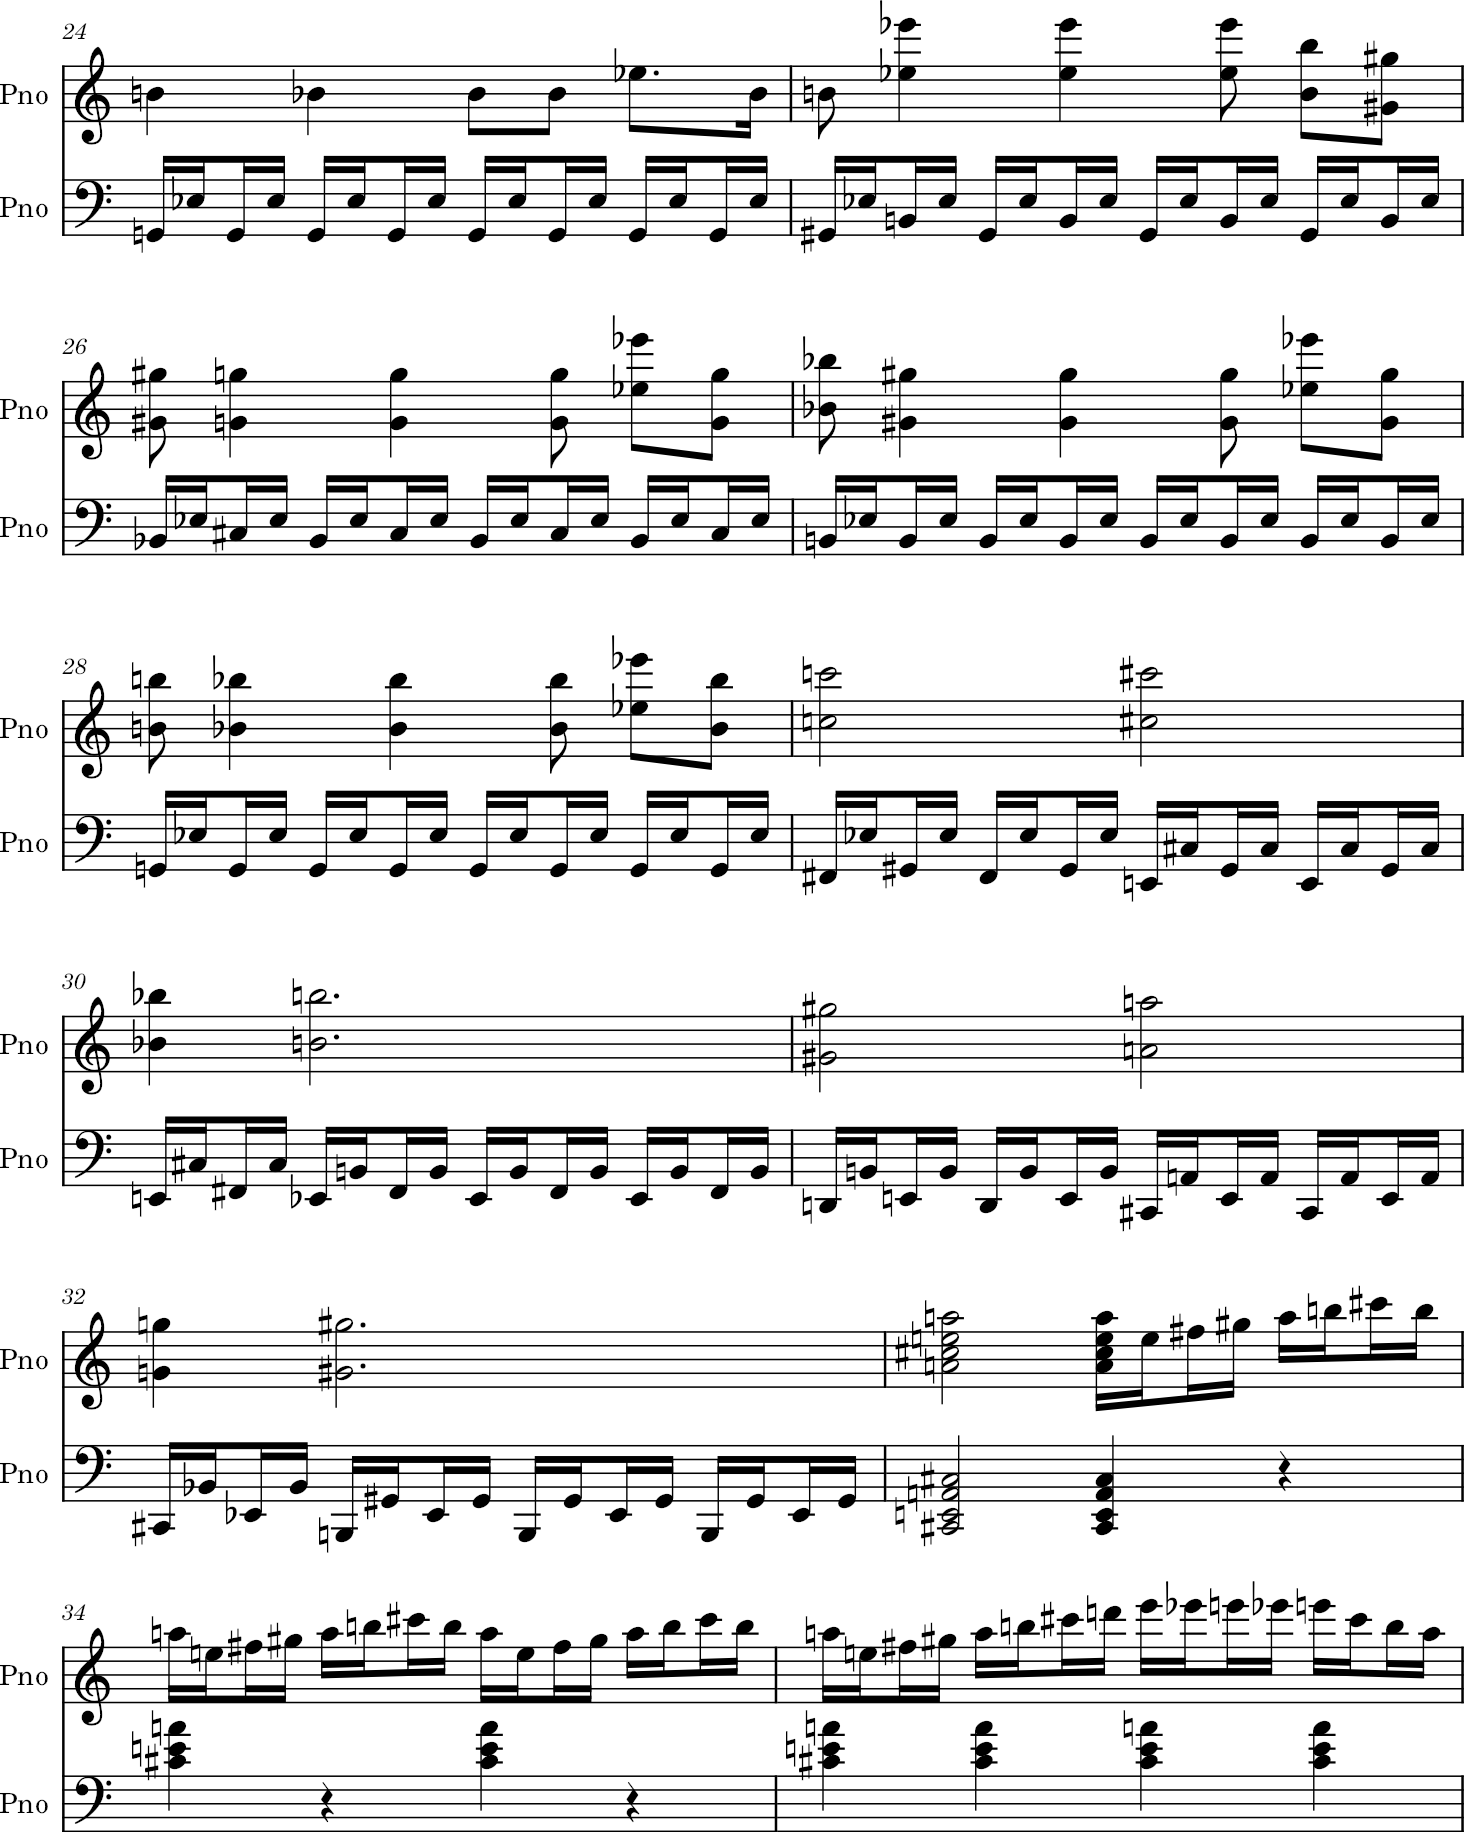

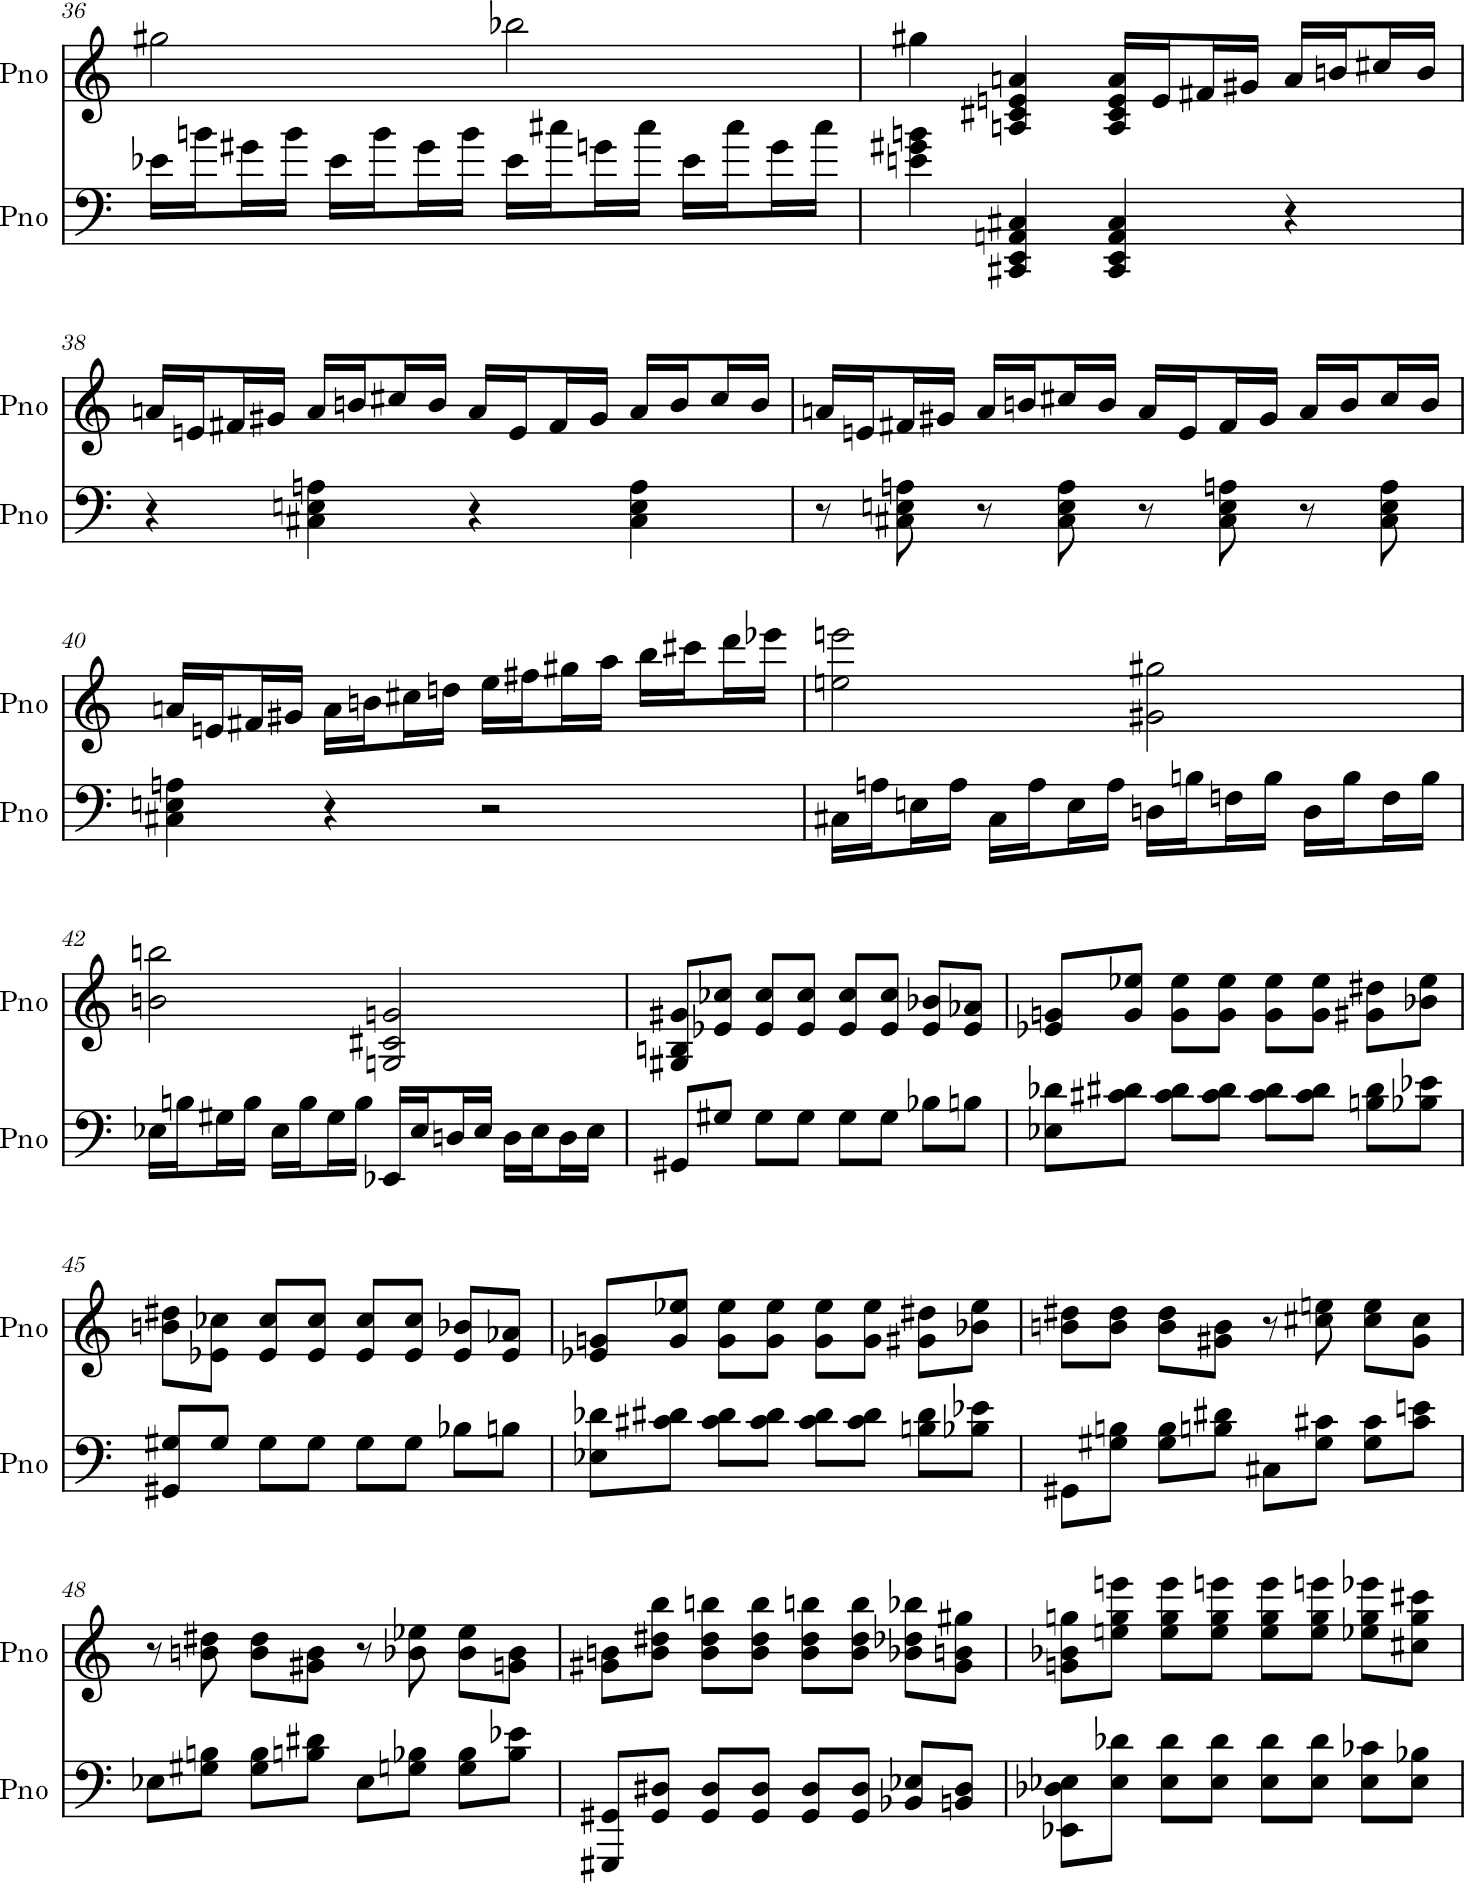

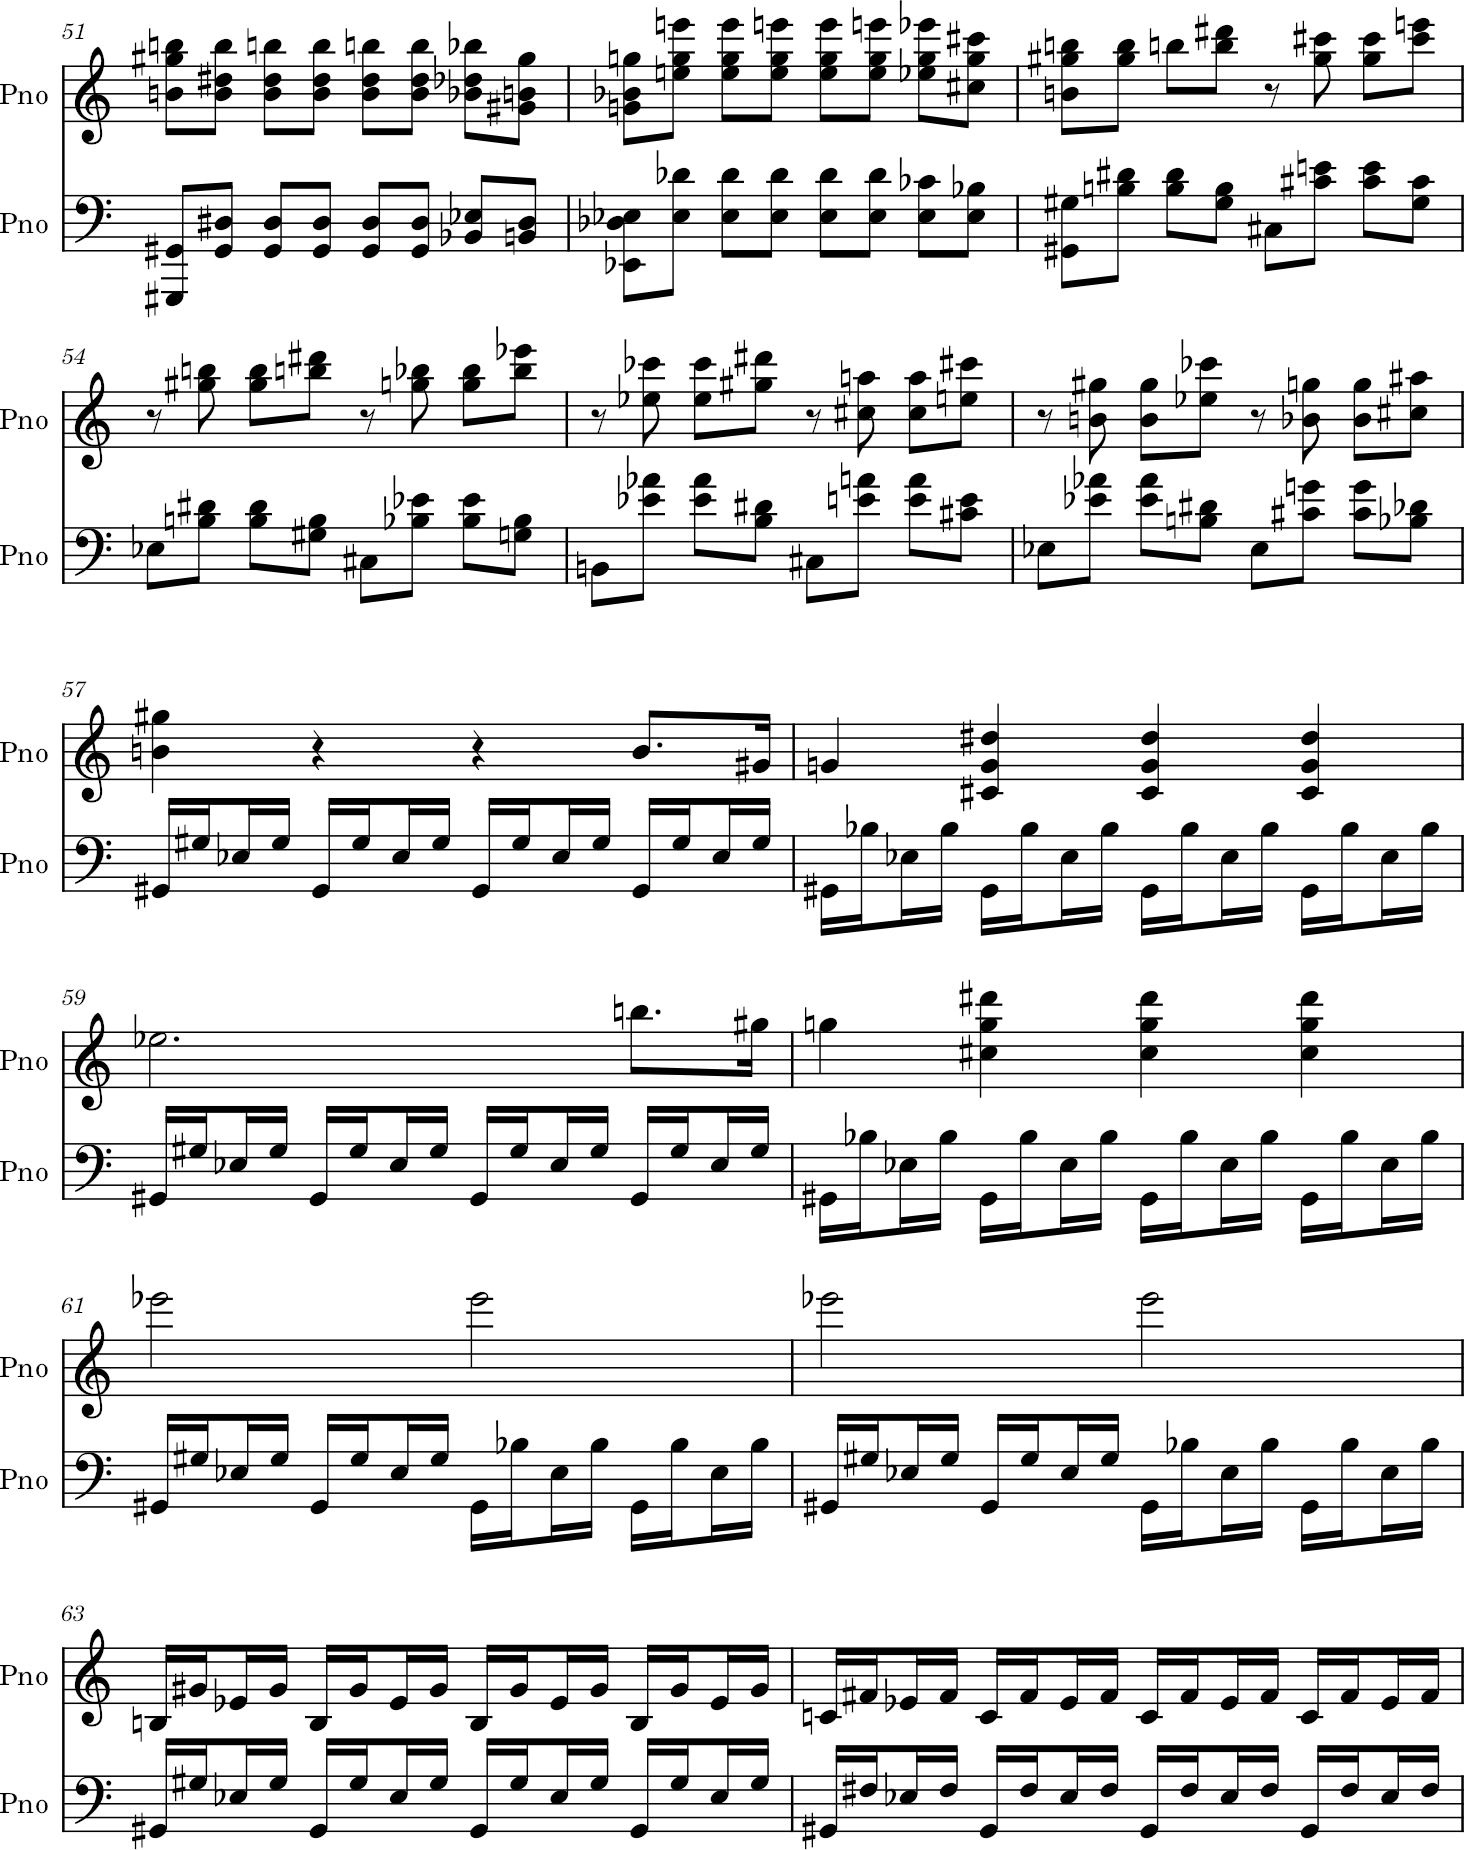

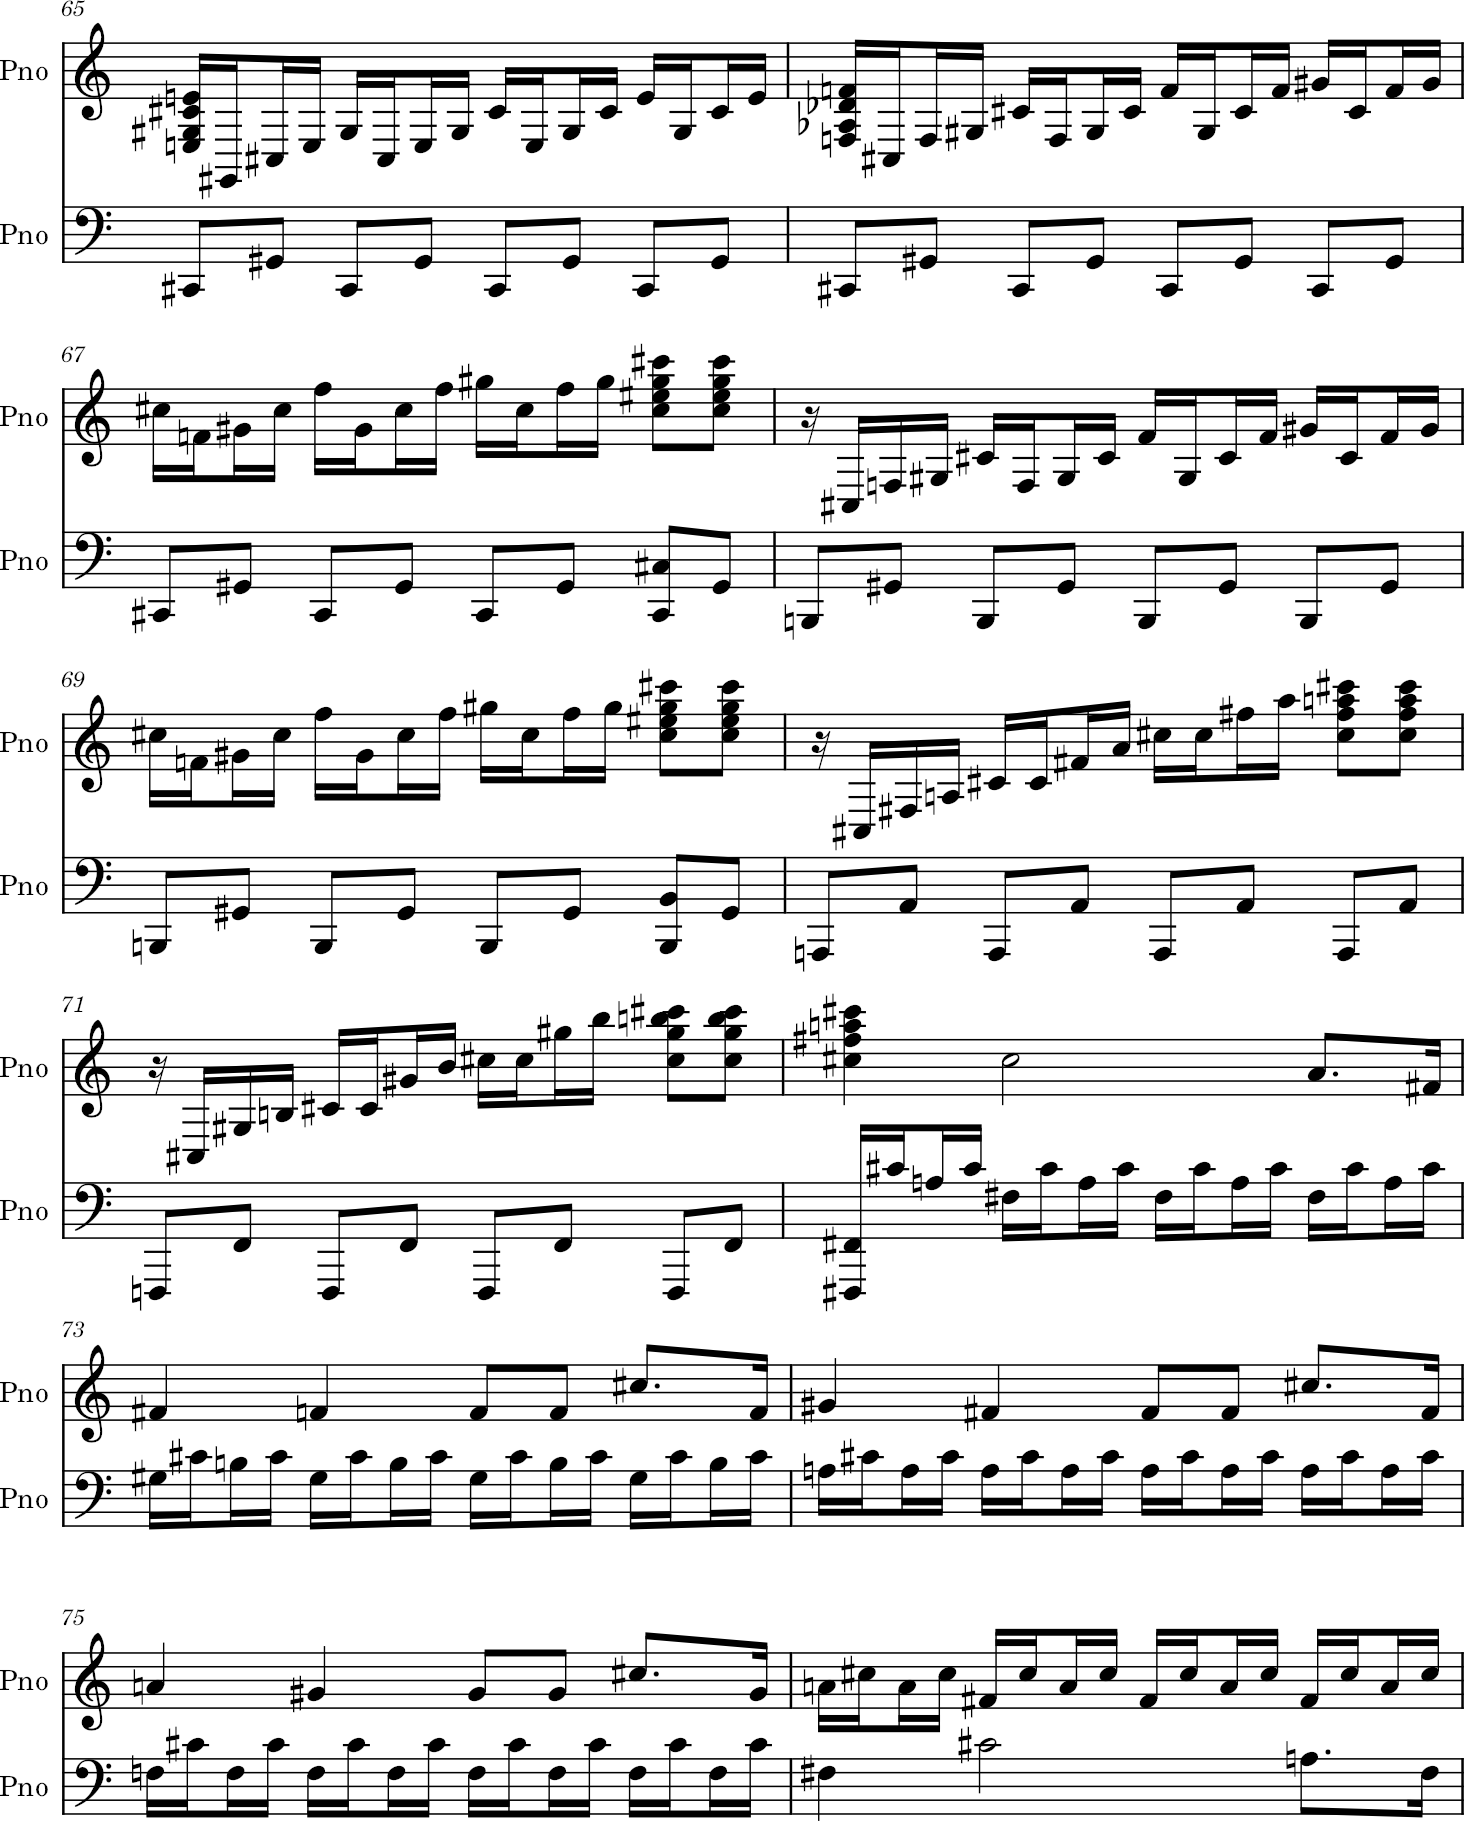

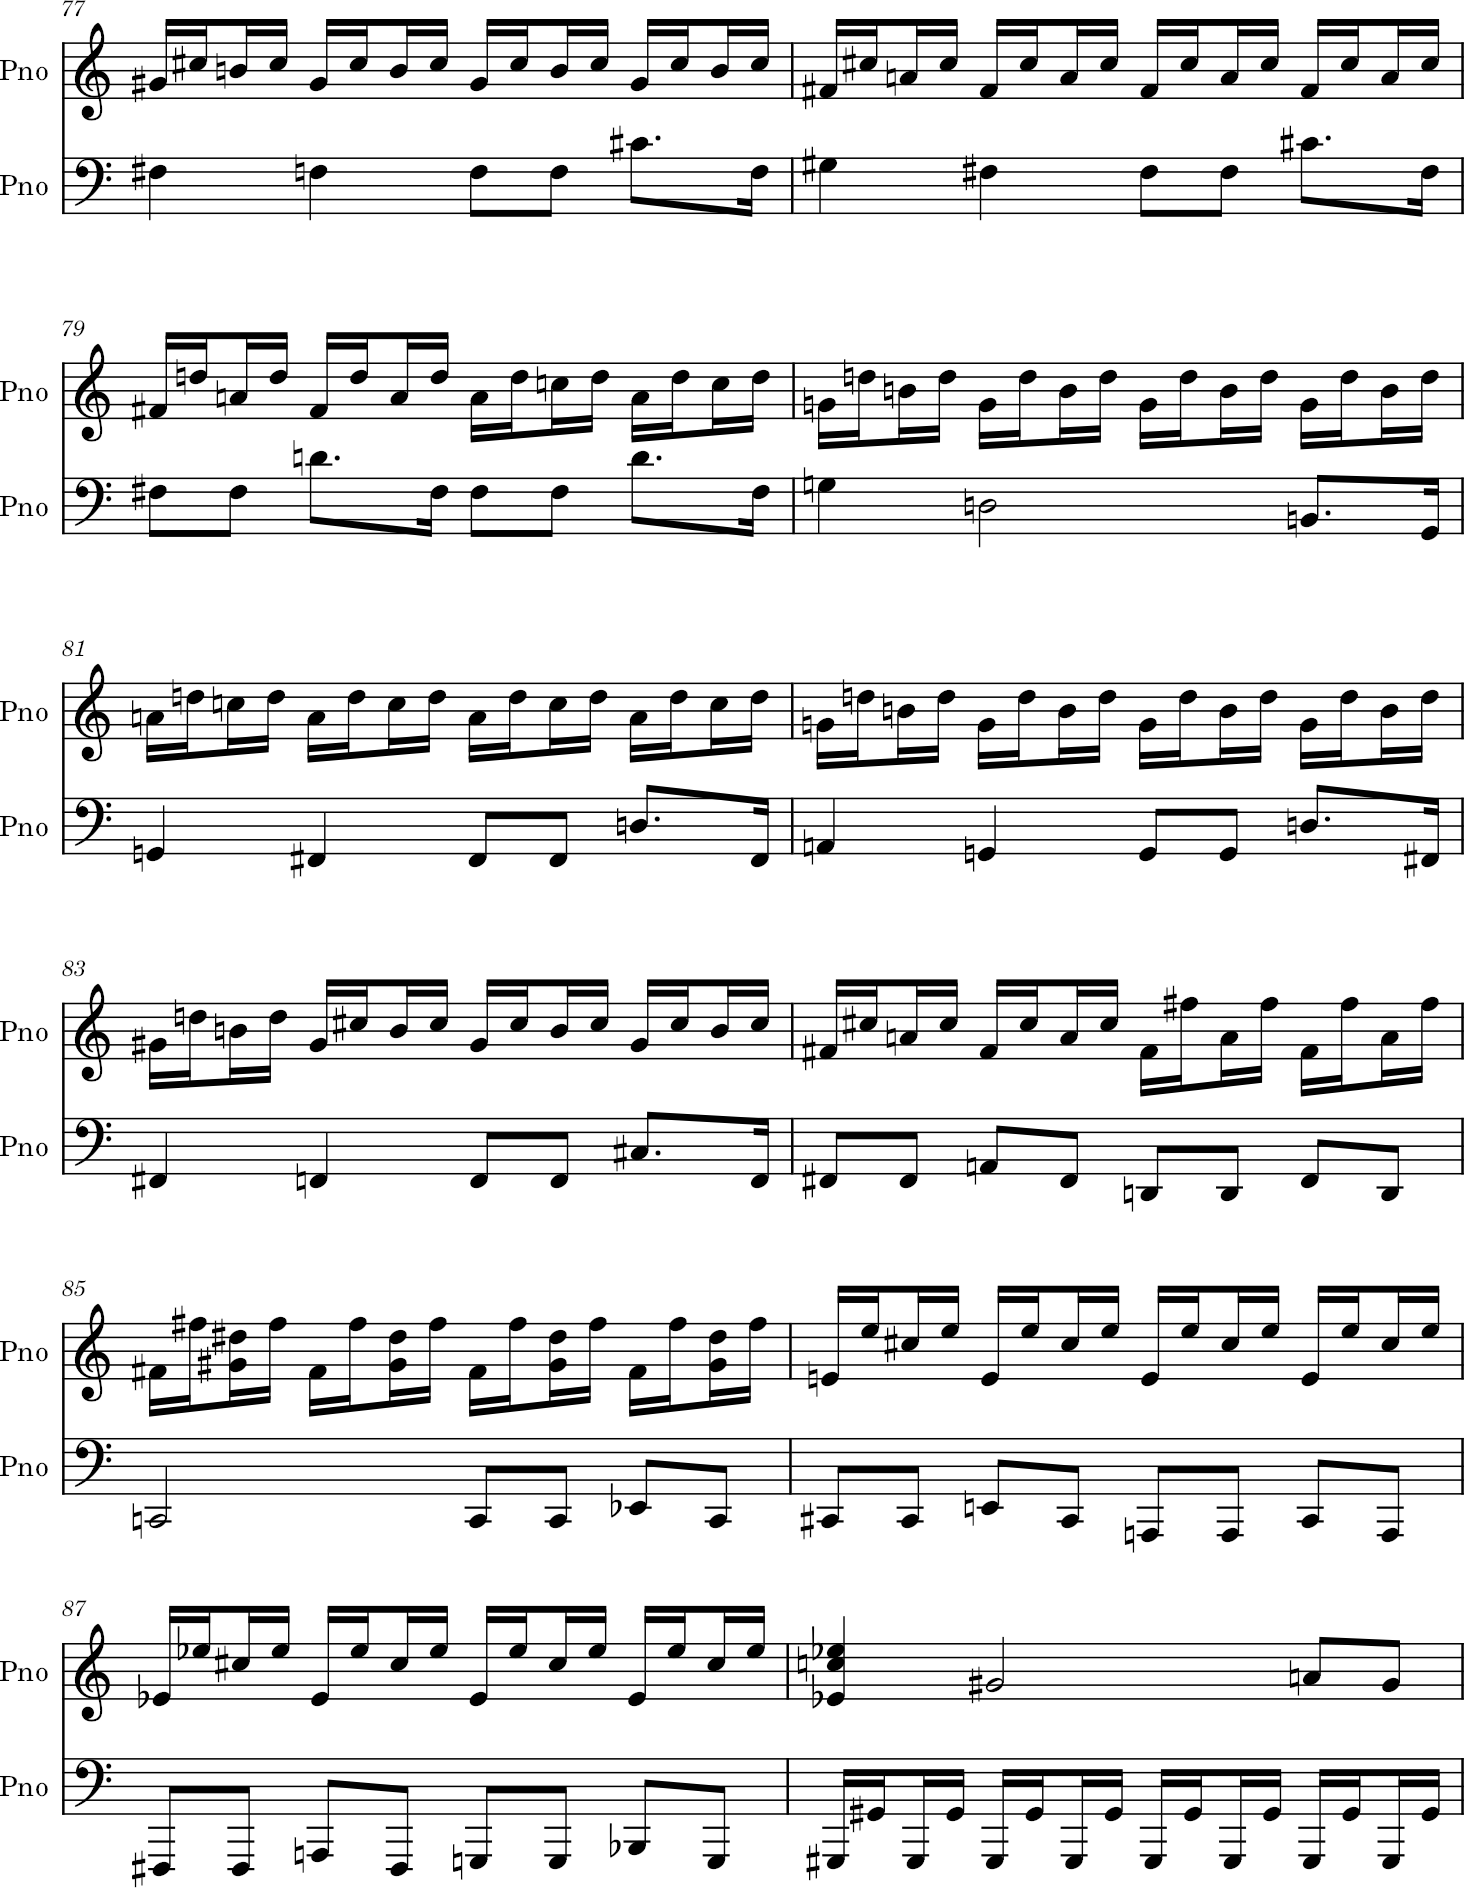

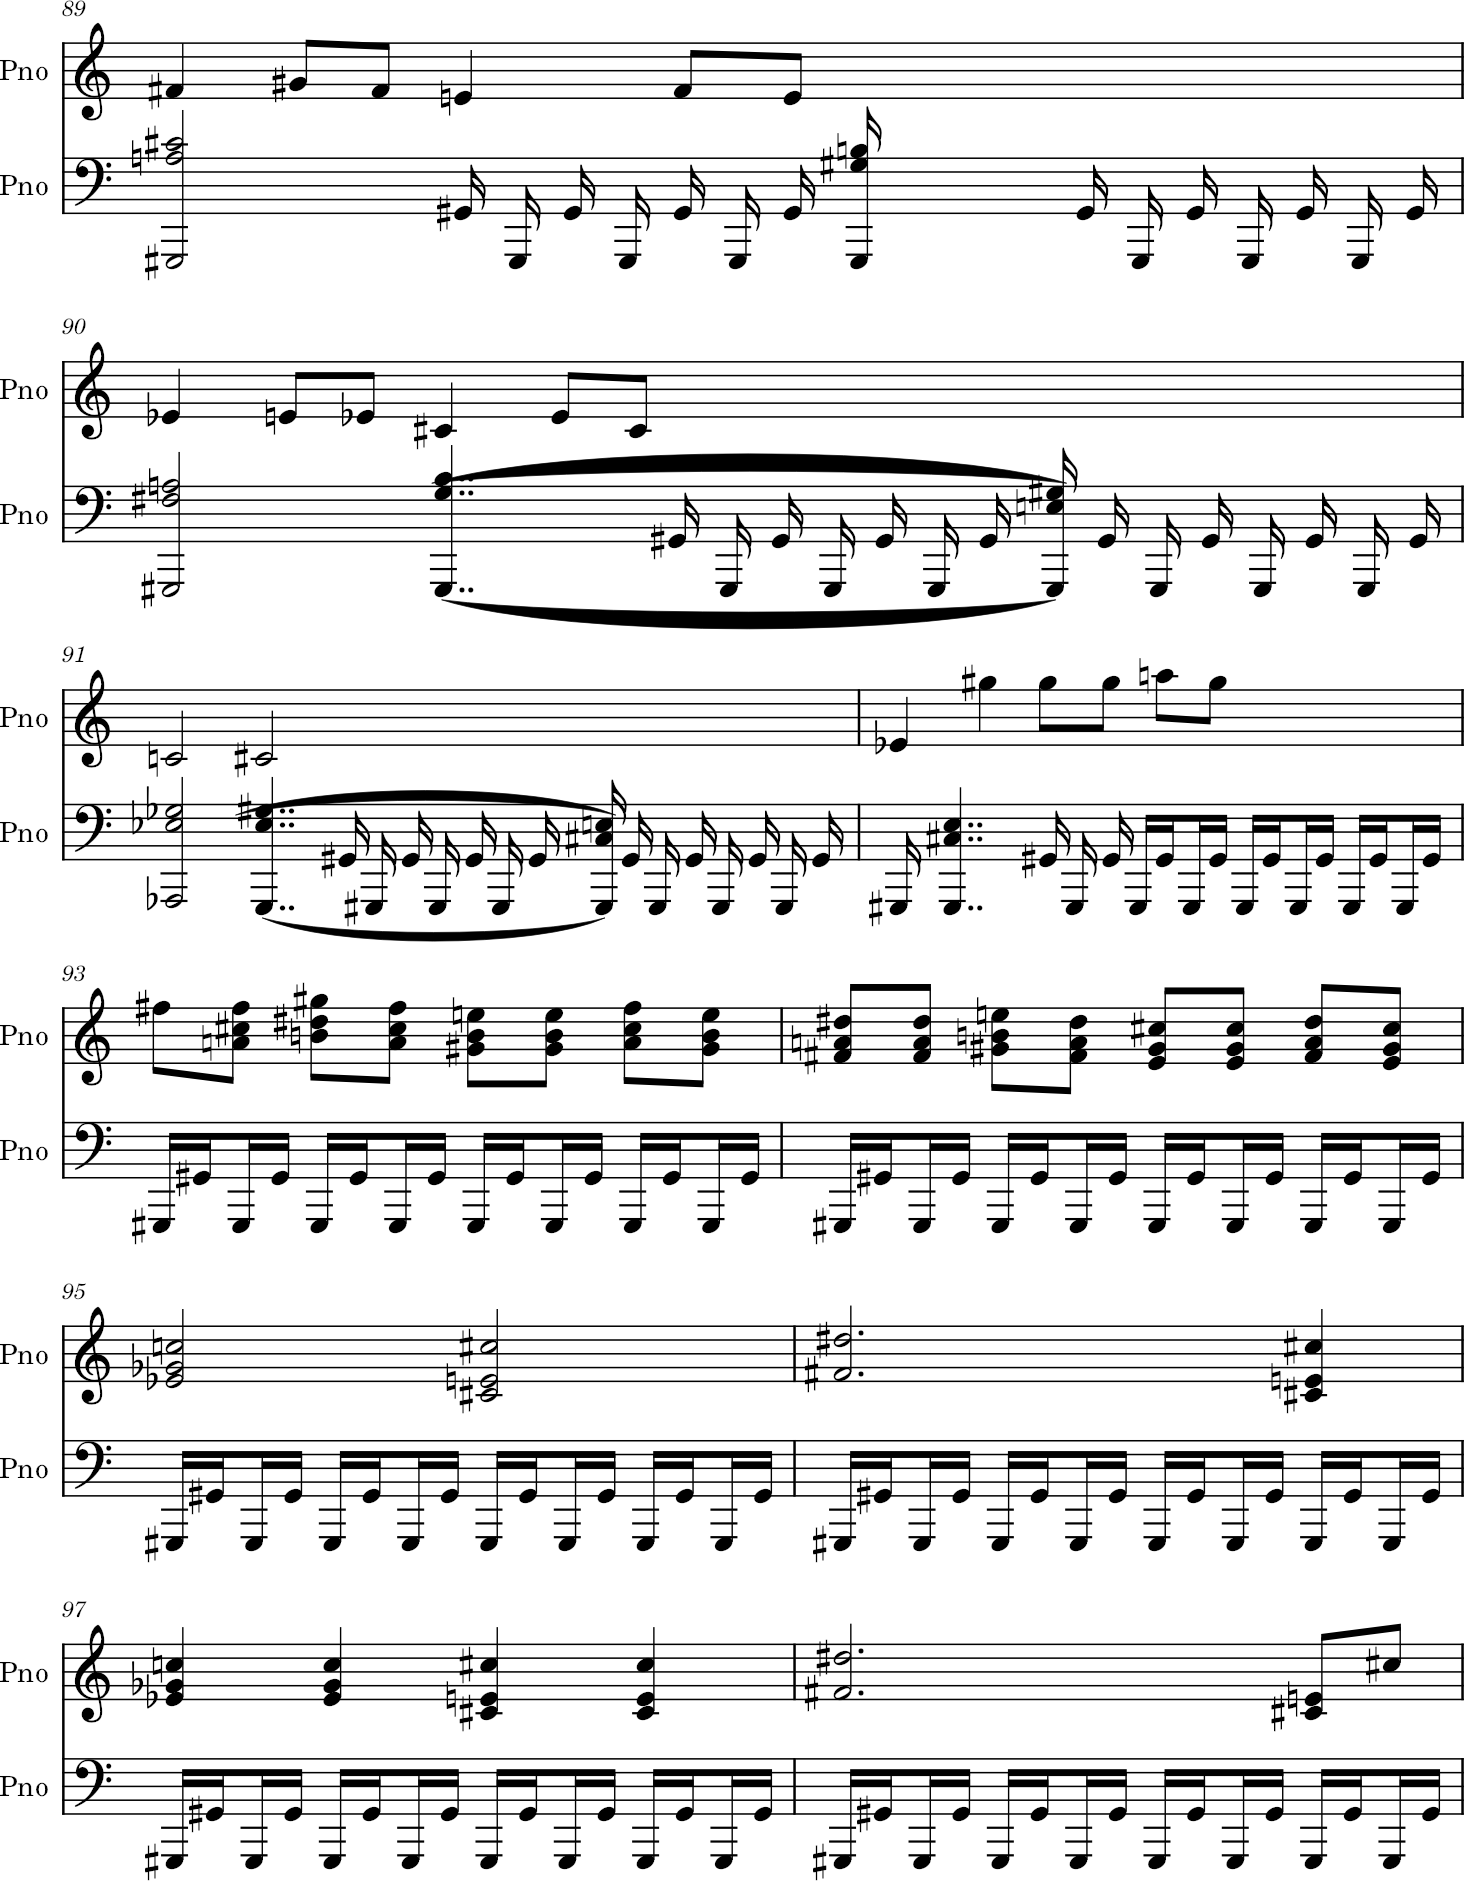

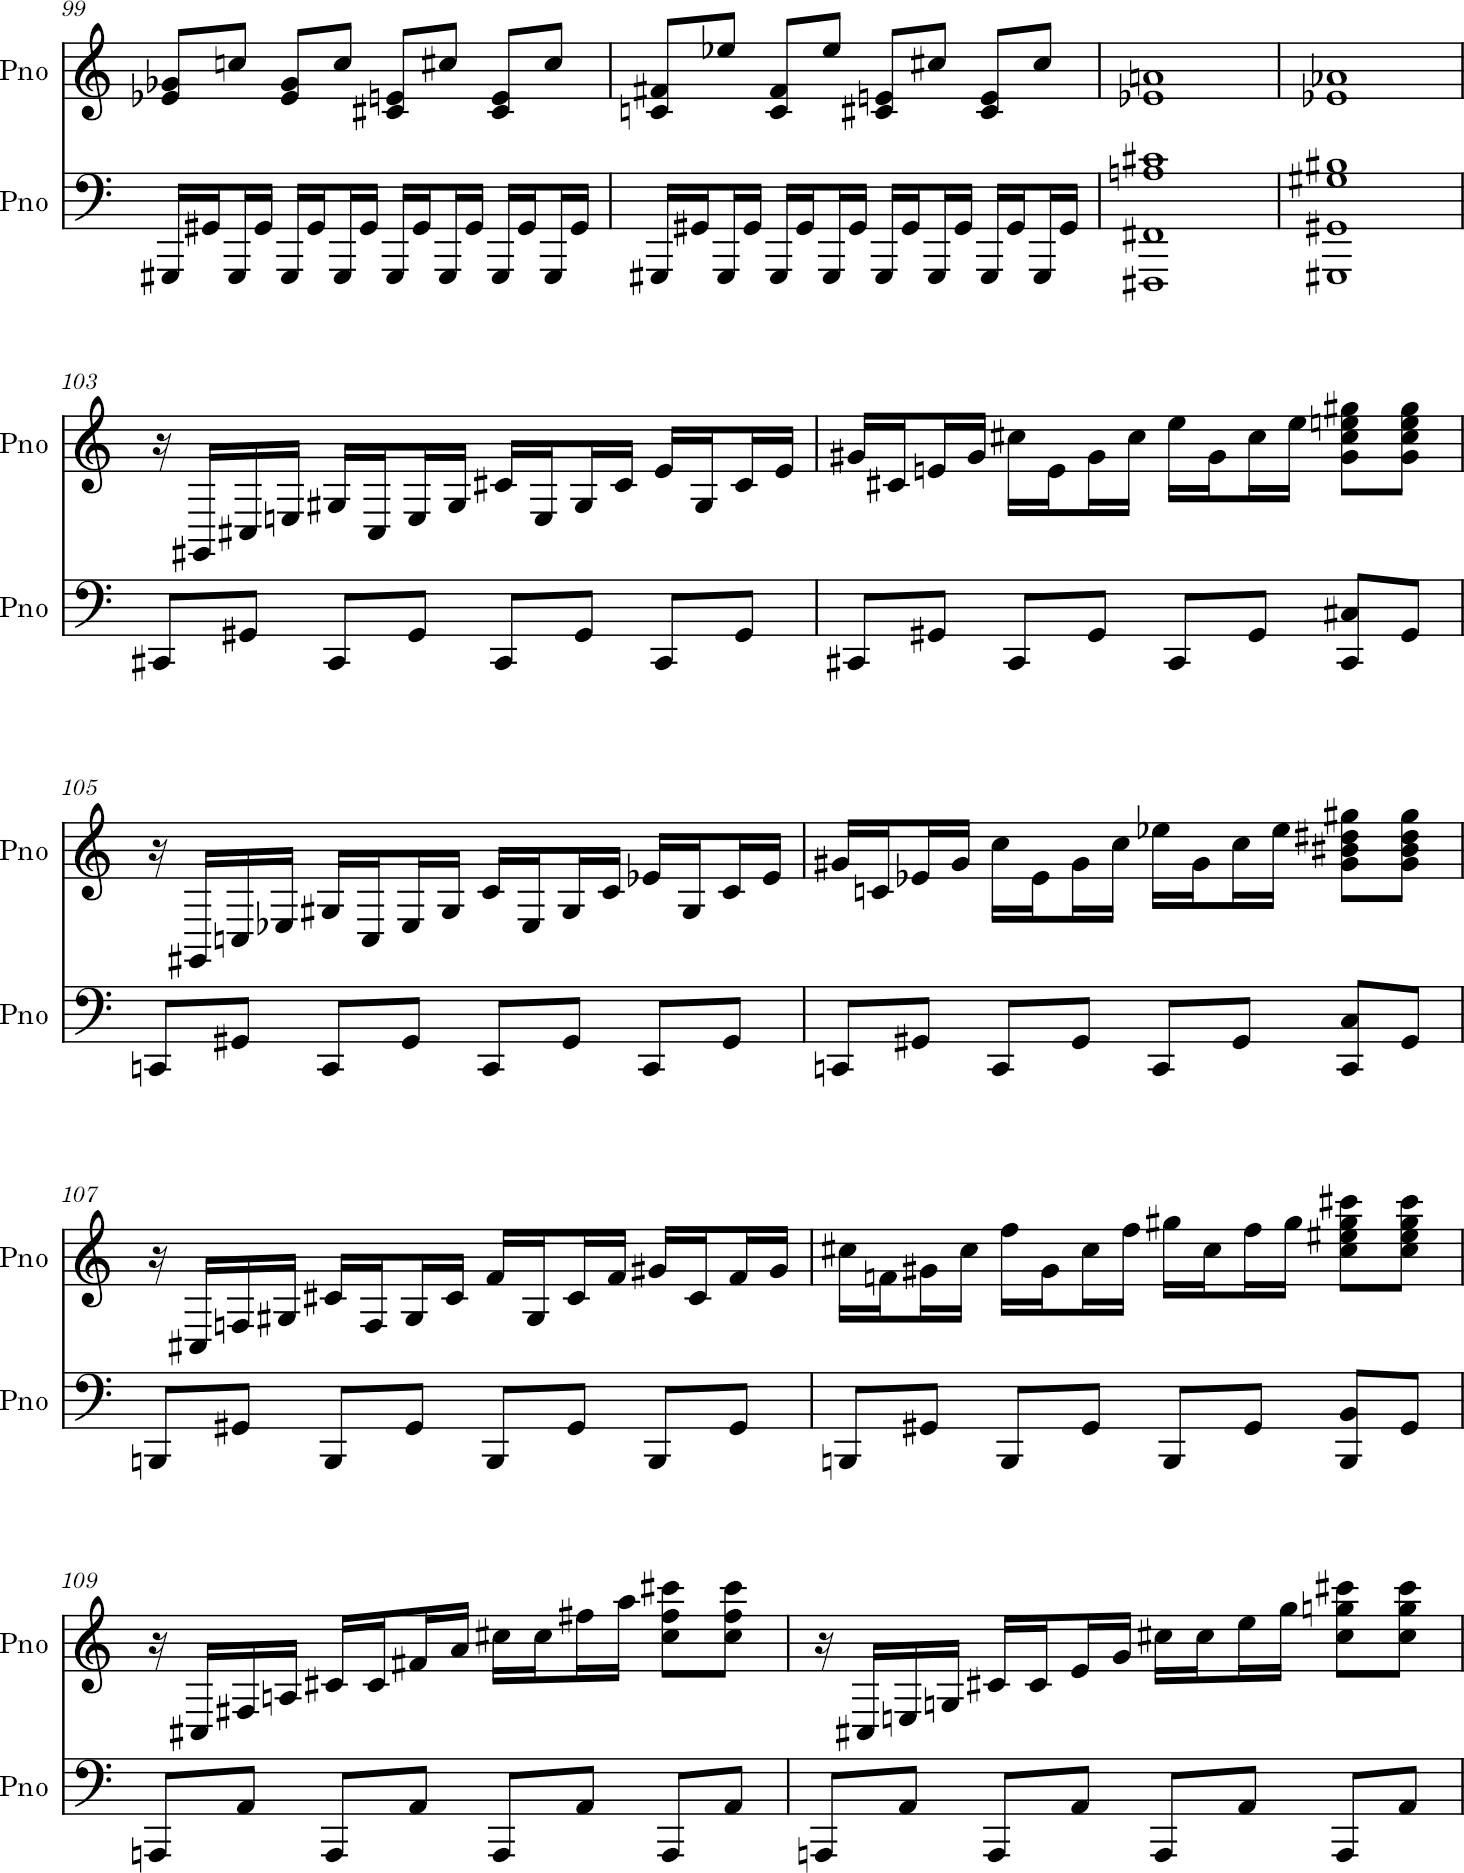

In [4]:
"""Cargar score"""

# score = converter.parse("data\Mozart_-_Lacrimosa_from_the_Requiem_in_D_minor.mxl")
# score = converter.parse("data\Mozart_K.488_Piano_Concerto_23_in_A_2nd_mov._Adagio_for_piano_solo.mxl")
score = converter.parse("partitura_generada.xml")
# score = converter.parse("data/humdrum-data/humdrum-data/beethoven/piano/sonata/beethoven-sonata01-1.krn")
score.show()

In [5]:
"""CODIDO ALFREDO"""
# matriz = process_notes(score)
matriz = np.load('array_merged.npy')
# matriz = np.load('data/beethoven-sonata01-1.npy',allow_pickle=True)

In [ ]:
path = r"data\humdrum-data-numpy\songs\folksongs\essen\asia\china\han\han0954"
voices = []
for filename in sorted(os.listdir(path)):
    if filename.endswith(".npy"):
        try:
            arr = np.load(f"{path}/{filename}")
        except:
            arr = np.load(f"{path}/{filename}",allow_pickle=True)
        voices.append(arr)
combined = np.vstack([voices[i] for i in range(len(voices))])
print(combined)
matriz = combined[combined[:, -1].argsort()]        

[[ 0.          0.5         0.5        70.          0.        ]
 [ 0.5         1.          0.5        72.          0.        ]
 [ 1.          1.25        0.25       75.          0.        ]
 [ 1.25        1.5         0.25       77.          0.        ]
 [ 1.5         1.75        0.25       75.          0.        ]
 [ 1.75        2.          0.25       72.          0.        ]
 [ 2.          2.25        0.25       75.          0.        ]
 [ 2.25        2.5         0.25       77.          0.        ]
 [ 0.          1.5         1.5        77.          1.        ]
 [ 1.5         2.          0.5        72.          1.        ]
 [ 0.          0.5         0.5        70.          2.        ]
 [ 0.5         1.          0.5        72.          2.        ]
 [ 1.          1.5         0.5        75.          2.        ]
 [ 0.          1.          1.         75.          3.        ]
 [ 1.          1.25        0.25       77.          3.        ]
 [ 1.25        1.5         0.25       75.          3.  

In [110]:
data = matriz # la matriz
onsets_negras = np.array([]) # iniciamos array de oonsets 
cum = 0 # iniciamos la suma acumulativa
for i in np.unique(data[:,4]): # iteramos compases
    array = data[np.where(data[:,4] == i),:][0] #seleccionamos array del compas
    if len(onsets_negras) > 0: # el primer compas cum = 0
        cum = np.max(array[:,1]) + cum # el segundo compas es cum = offset más alto
    array = array[~np.any(array[:,:] == -1, axis=1)] # para eliminar silencios
    array =  array[array[:, 0].argsort()]    # ordenar por onsets
    array = np.unique(array[:,0]) # eliminar onsets repetidos
    array = array + cum # sumamos el cum
    onsets_negras = np.concatenate((onsets_negras,array)) # lo añadimos 

"""onsets está listo para ser analizado por multitapers"""
# print(data)
print(onsets_negras)

[ 0.25   0.5    0.75   1.     1.5    1.75   2.     2.25   2.75   3.
  3.25   3.5    4.     4.25   4.5    4.75   5.25   5.5    5.75   6.
  6.25   6.5    6.75   7.     7.25   7.75   8.     8.25   8.5    8.75
  9.     9.25   9.5    9.75  10.    10.25  10.5   11.    11.25  11.5
 11.75  12.    12.5   12.75  13.    13.625 13.75  13.875 14.    14.125
 14.25  14.375 14.625 14.75  15.    15.125 15.375 15.625 15.75  15.875
 16.    16.125 16.25  16.375 16.5   16.625 16.75  16.875 17.    17.25
 17.375 17.75  18.    18.25  18.5   18.625 18.75  18.875 19.    19.125
 19.25  19.375 19.5   19.625 19.75  19.875 20.    20.25  20.375 20.75
 21.    21.25  21.5   21.625 21.75  21.875 22.    22.125 22.25  22.375
 22.5   22.625 22.75  22.875 23.    23.125 23.25  23.375 23.5   23.625
 23.75  23.875 24.    24.125 24.25  24.375 24.5   24.625 24.75  24.875
 25.    25.125 25.25  25.625 25.75  25.875 26.    26.125 26.25  26.375
 26.5   26.625 26.75  26.875 27.25  27.5   27.75  28.    28.5   28.75
 29.    29.25  29.

In [105]:
midi_to_note(80)

'G#5'

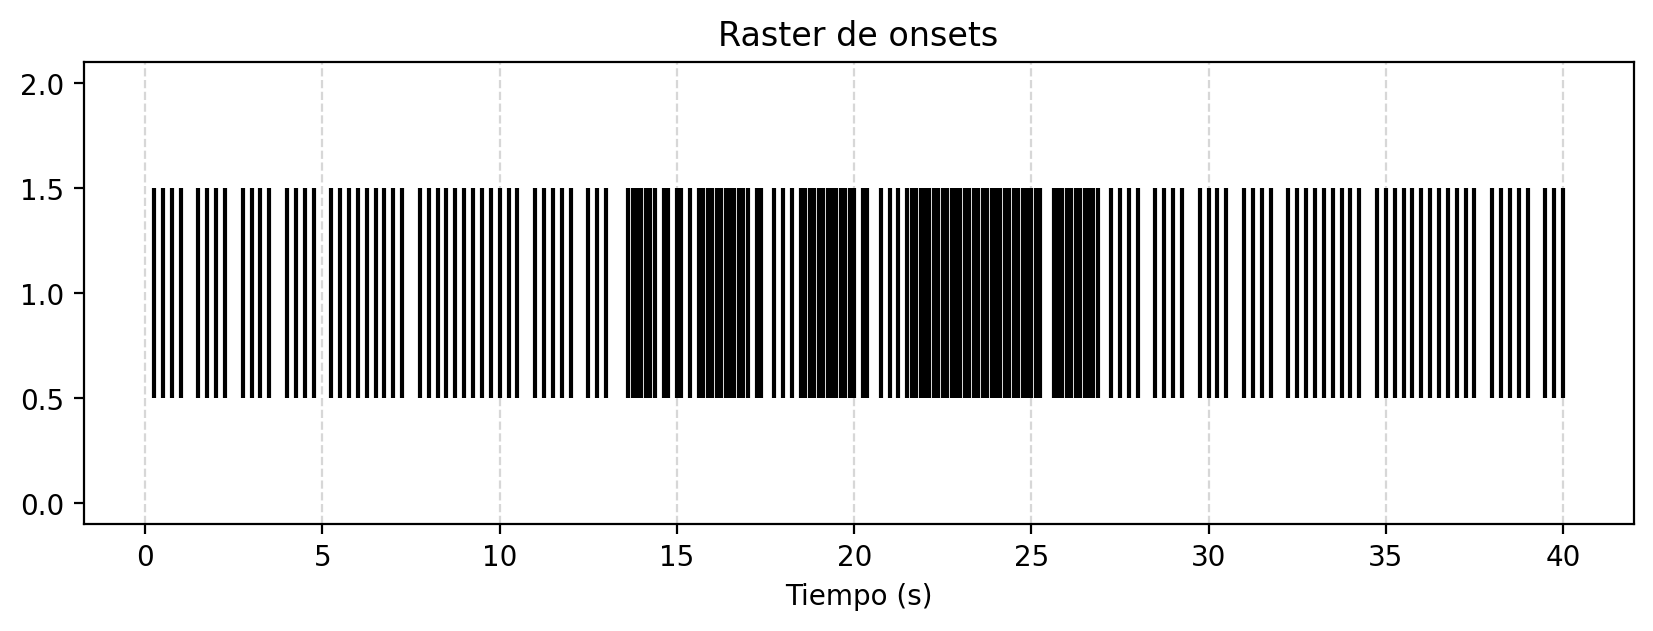

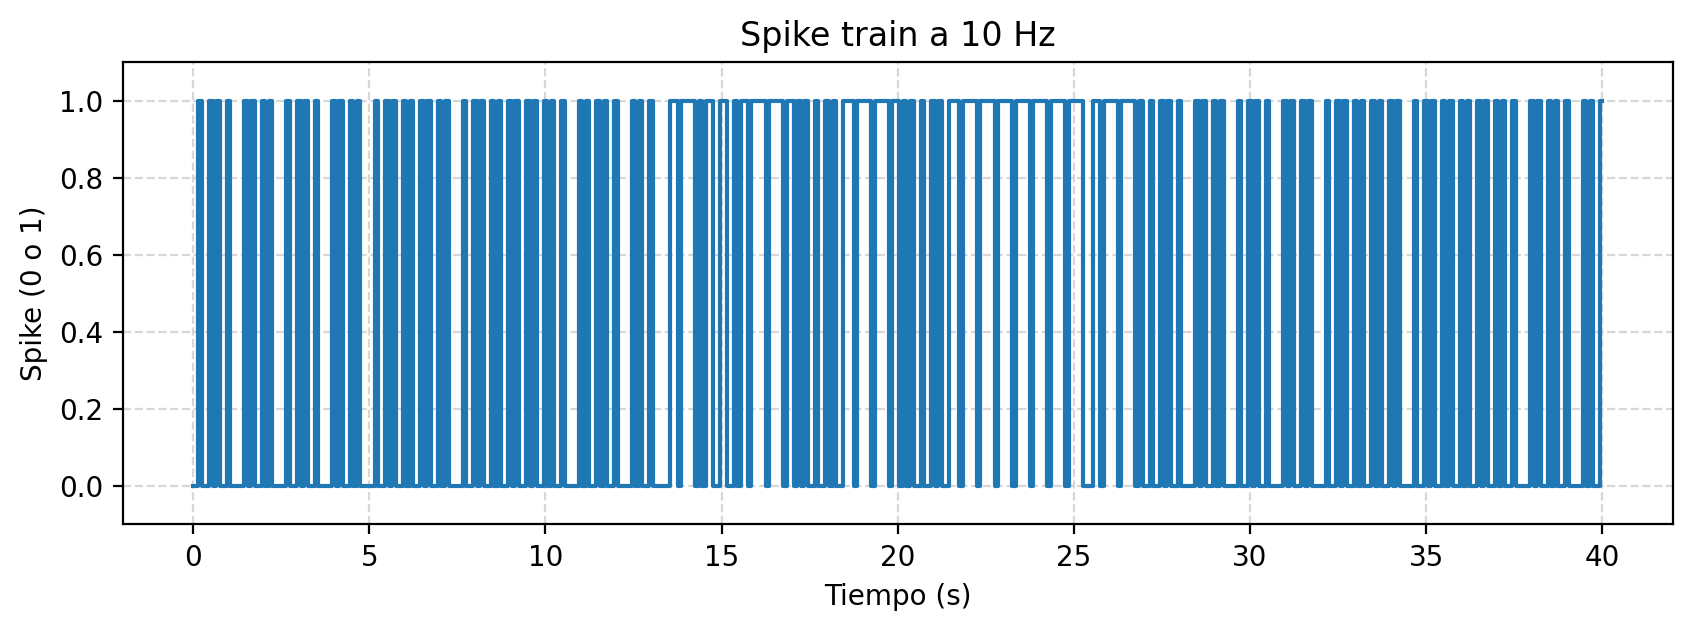

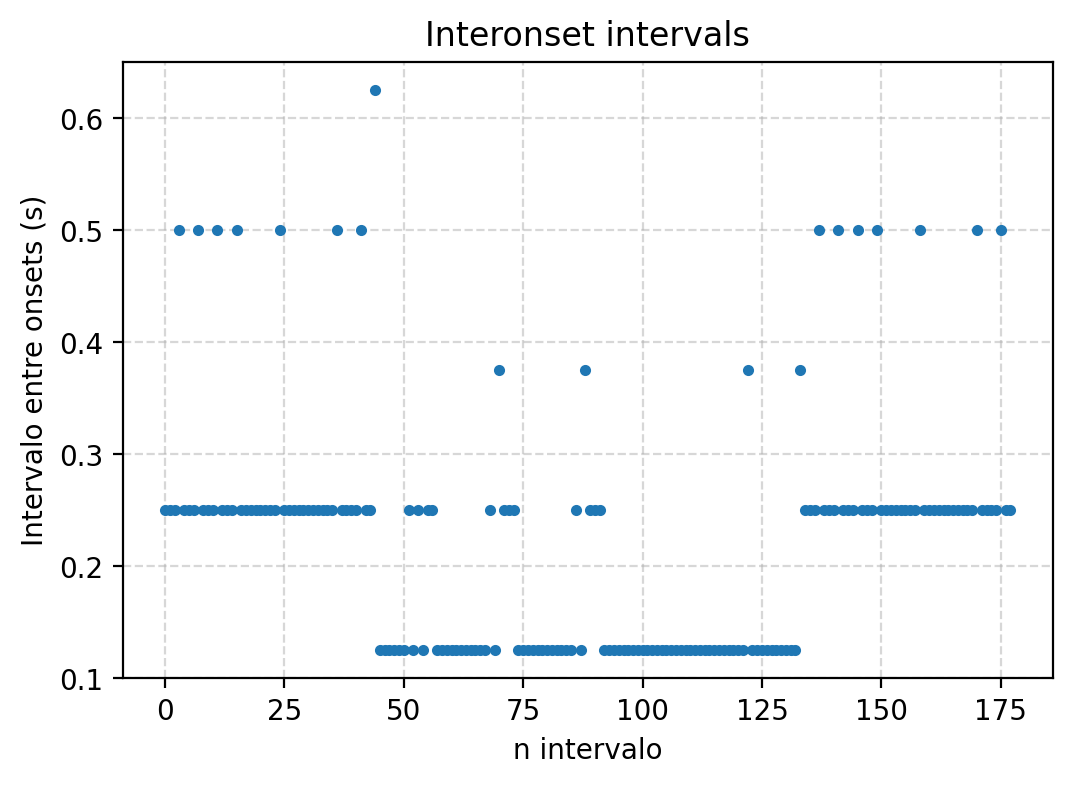

In [111]:
import numpy as np

# Ejemplo: tu matriz cargada
# matriz = np.loadtxt('mi_matriz.csv', delimiter=',')

# Calcular interonset intervals
interonset_intervals = np.diff(onsets_negras)

if False:
    interonset_intervals = np.random.permutation(interonset_intervals)
    onsets_negras = np.concatenate([[onsets_negras[0]], onsets_negras[0] + np.cumsum(interonset_intervals)])


# Crear spike train a 10 Hz (10 muestras por segundo)
fs = 10  # frecuencia de muestreo (Hz)
dt = 1 / fs

# Eje temporal
t_max = np.max(onsets_negras) + dt
t_axis = np.arange(0, t_max, dt)

# Inicializar spike train
spike_train = np.zeros_like(t_axis)

# Marcar spikes en el bin más cercano
for onset in onsets_negras:
    idx = np.argmin(np.abs(t_axis - onset))
    spike_train[idx] = 1

# --- Raster: spikes sobre eje temporal ---
plt.figure(figsize=(10, 3))
plt.eventplot(onsets_negras, orientation='horizontal', colors='black')
plt.xlabel('Tiempo (s)')
plt.title('Raster de onsets')
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.show()

# --- Spike train como señal binaria ---
plt.figure(figsize=(10, 3))
plt.step(t_axis, spike_train, where='mid')
plt.xlabel('Tiempo (s)')
plt.ylabel('Spike (0 o 1)')
plt.title('Spike train a 10 Hz')
plt.ylim(-0.1, 1.1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# --- Histograma de interonset intervals ---
plt.figure(figsize=(6, 4))
plt.plot(interonset_intervals,'.')
plt.xlabel('n intervalo')
plt.ylabel('Intervalo entre onsets (s)')
plt.title('Interonset intervals')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()



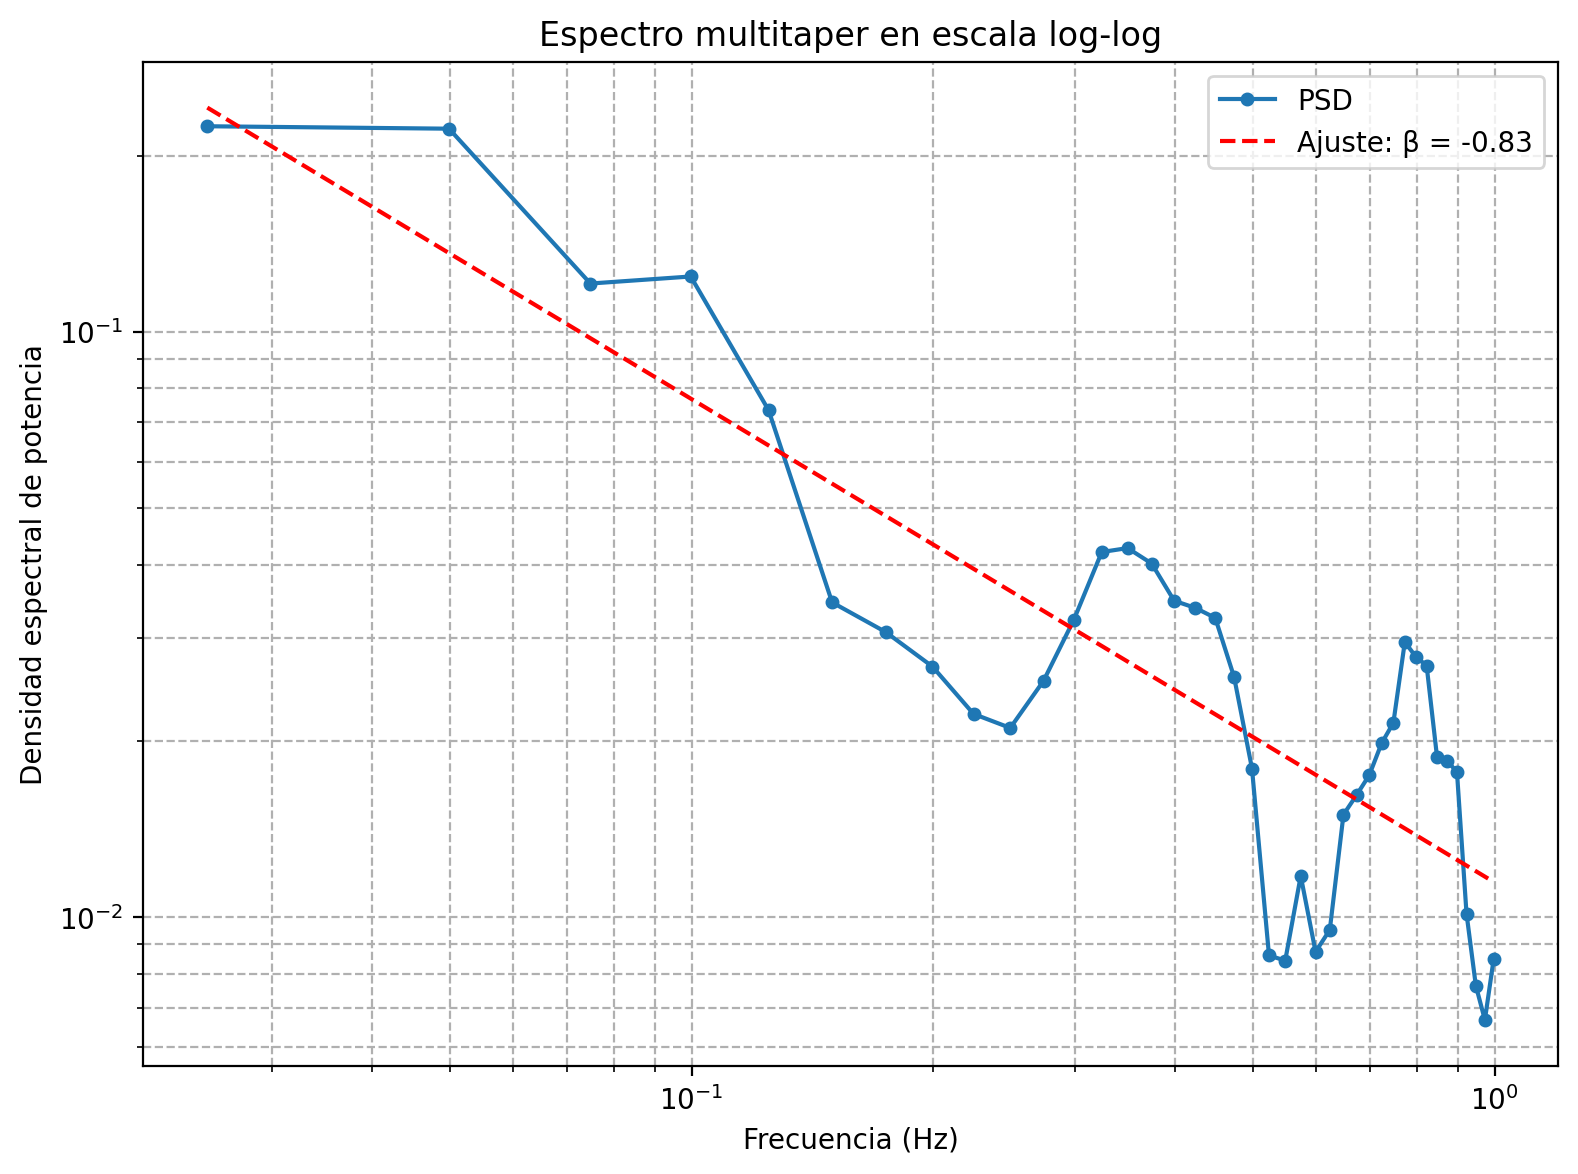

In [112]:
import numpy as np
import matplotlib.pyplot as plt
from mne.time_frequency import psd_array_multitaper
from scipy.stats import linregress

# 1. Interpolación lineal del spike train (si no se ha hecho antes)
# spike_train = interpolar_spike_train(onsets, fs)  # <- Aquí va tu función de interpolación

# 2. Cálculo del espectro de potencia usando multitaper
psd, freqs = psd_array_multitaper(
    spike_train,
    sfreq=fs,
    fmin=0.01,
    fmax=1.0,
    adaptive=True,
    normalization='full',
    verbose=False
)

# 3. Transformación a escala log-log
mask = (freqs > 0)  # Evitar log(0)
log_freqs = np.log10(freqs[mask])
log_psd = np.log10(psd[mask])

# 4. Ajuste lineal en la región de interés (región de potencias tipo ley de potencias)
roi = (freqs[mask] >= 0.01) & (freqs[mask] <= 1.0)
slope, intercept, r_value, p_value, std_err = linregress(log_freqs[roi], log_psd[roi])

# 5. Gráfica del espectro y la ley de potencias ajustada
plt.figure(figsize=(8, 6))
plt.plot(freqs, psd, 'o-', label='PSD', markersize=4)
plt.plot(
    freqs[mask][roi],
    10**(intercept + slope * log_freqs[roi]),
    'r--',
    label=f'Ajuste: β = {slope:.2f}'
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral de potencia')
plt.title('Espectro multitaper en escala log-log')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()


In [51]:
print(J_univariante(interpolador(generar_uniforme_centrada(10000,1e-5),'lineal',10)[1]))

0.8897919029200937


4401
0.7294621421328904


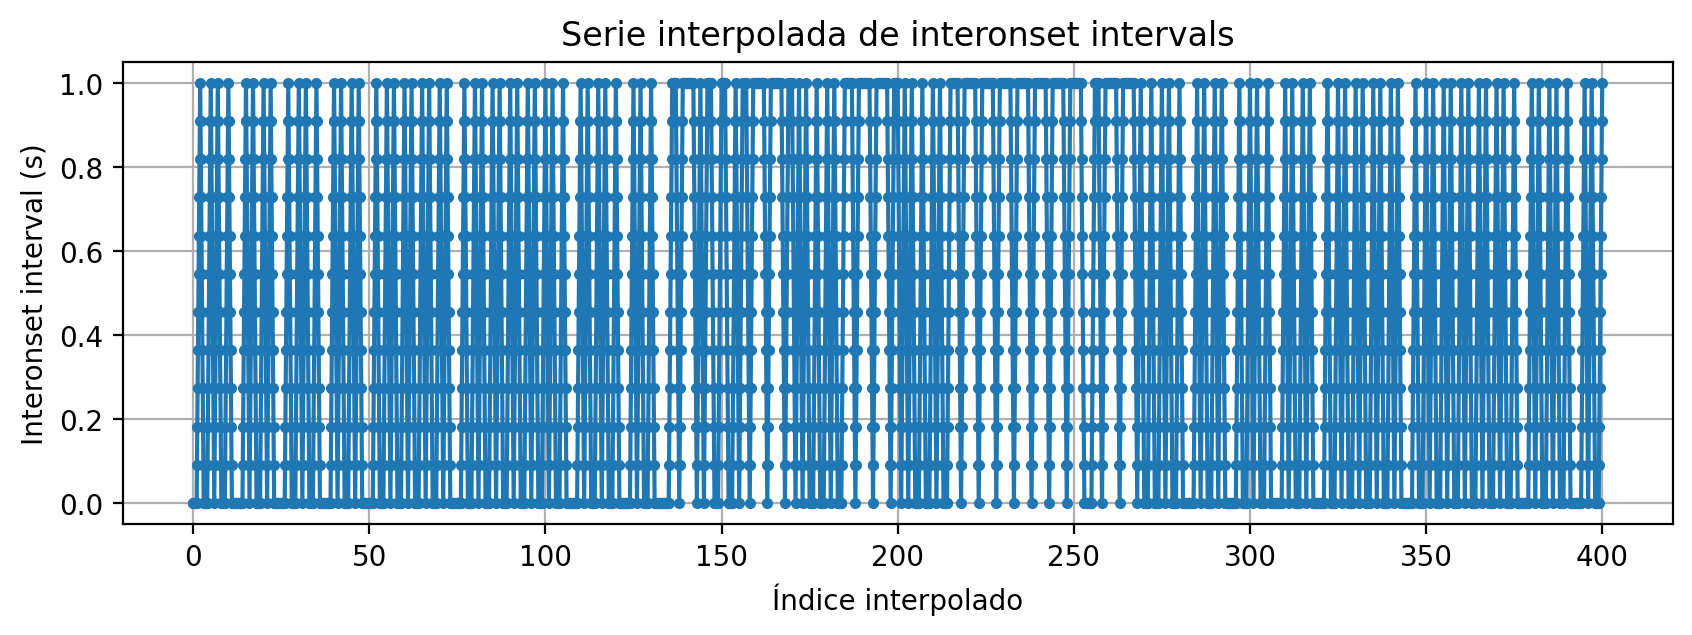

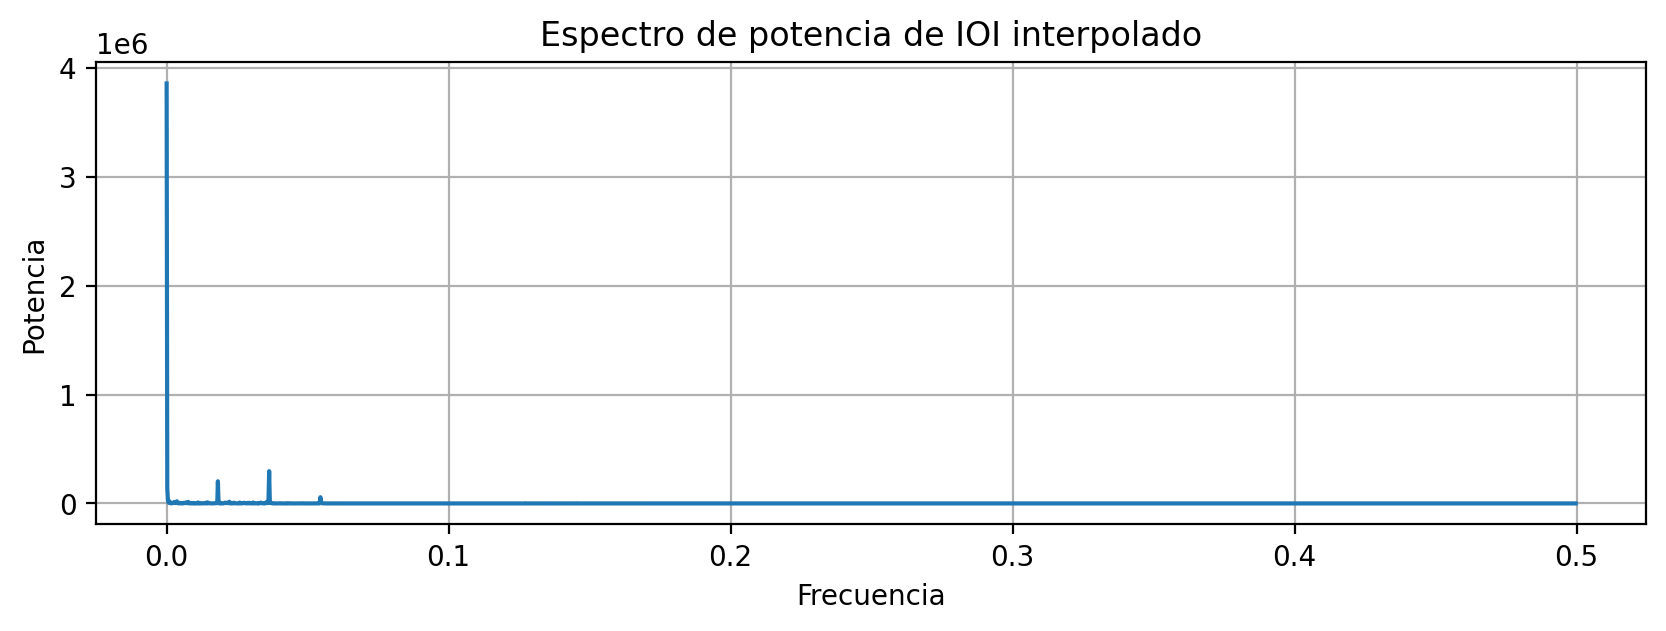

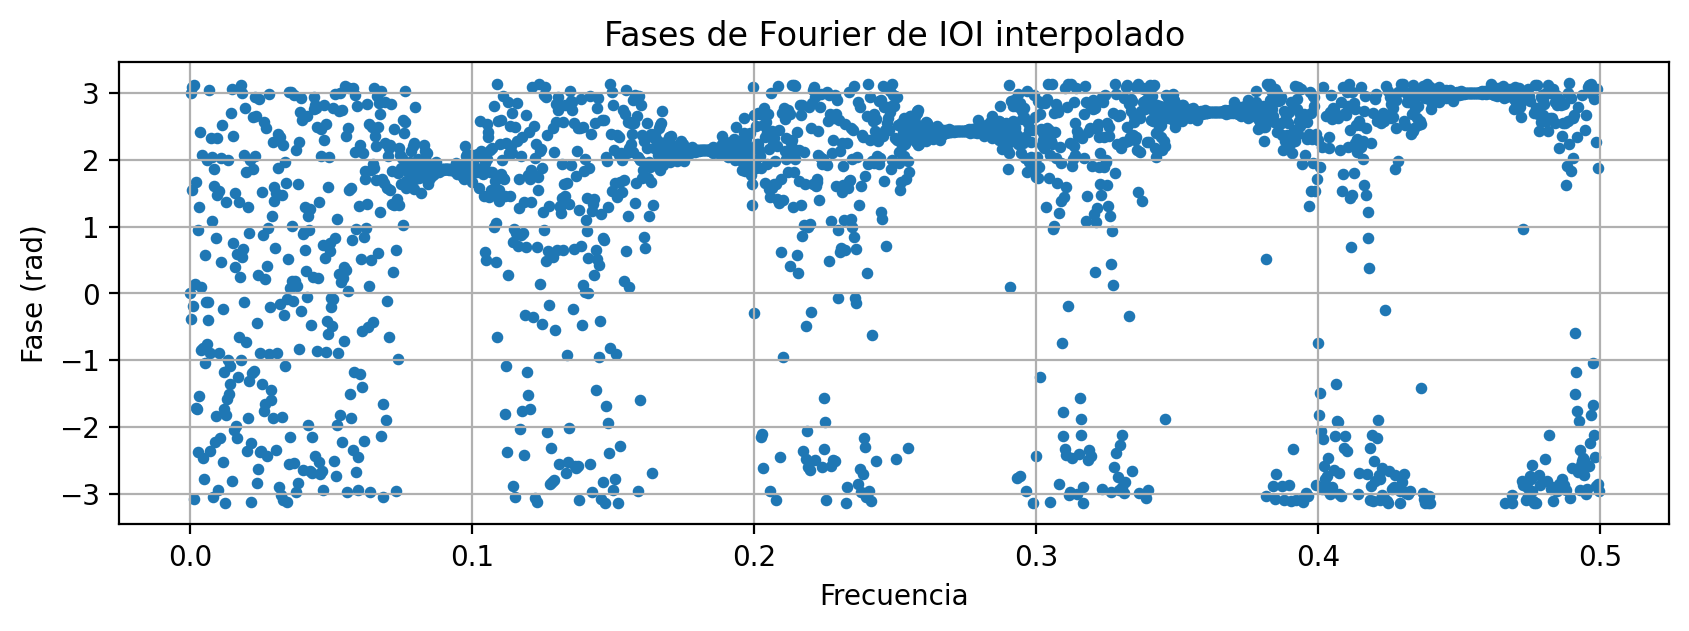

In [114]:
from scipy.interpolate import PchipInterpolator
from scipy.fft import fft


x_new, ioi_interp = interpolador(spike_train, method='lineal', size=10)
print(len(ioi_interp))
# === FFT ===
fft_result = fft(ioi_interp)
power = np.abs(fft_result)**2
phase = np.angle(fft_result)

# === Frecuencias asociadas ===
fs = 1  # Como estamos trabajando en índice de IOIs (no en tiempo real), fs=1
freqs = np.fft.fftfreq(len(ioi_interp), d=1/fs)

# === Gráficas ===

# Serie interpolada
plt.figure(figsize=(10, 3))
plt.plot(x_new, ioi_interp,'.-')
plt.title('Serie interpolada de interonset intervals')
plt.xlabel('Índice interpolado')
plt.ylabel('Interonset interval (s)')
plt.grid(True)

# Espectro de potencia
plt.figure(figsize=(10, 3))
plt.plot(freqs[:len(freqs)//2], power[:len(freqs)//2])
plt.title('Espectro de potencia de IOI interpolado')
plt.xlabel('Frecuencia')
plt.ylabel('Potencia')
plt.grid(True)

# Fases de Fourier
print(J_univariante(ioi_interp))
plt.figure(figsize=(10, 3))
plt.scatter(freqs[:len(freqs)//2], phase[:len(freqs)//2], s=10)
plt.title('Fases de Fourier de IOI interpolado')
plt.xlabel('Frecuencia')
plt.ylabel('Fase (rad)')
plt.grid(True)

plt.show()
